In [1]:
#roi raw activation from selectivity_summary file
import pandas as pd
import numpy as np
from plotnine import (ggplot, aes, geom_point, geom_linerange, theme_classic, labs,
                      scale_color_manual, scale_shape_manual, theme, element_text, element_line, element_blank,
                      coord_cartesian, scale_x_discrete, guides, guide_legend)

# Read the CSV data with updated path
#data = pd.read_csv("/results/tools/selectivity/selectivity_summarytoolloc.csv")
data = pd.read_csv("/user_data/csimmon2/git_repos/ptoc/results/tools/selectivity/selectivity_summarytoolloc.csv")

# Filter data for spaceloc subjects and relevant ROIs
filtered_data = data[(data['sub'].str.contains('spaceloc')) & 
                     (data['roi'].isin(['PFS', 'aIPS'])) & #(data['roi'].isin(['LO', 'pIPS']))
                     (data['hemi'].isin(['left', 'right']))]

# Calculate mean activation and standard deviation for each combination
summary_df = filtered_data.groupby(['hemi', 'roi', 'cond'])['mean_act'].agg(['mean', 'std', 'count']).reset_index()
summary_df['sem'] = summary_df['std'] / np.sqrt(summary_df['count'])

# Rename columns for clarity
summary_df.columns = ['Hemisphere', 'ROI', 'Condition', 'Mean', 'Std', 'Count', 'SE']

# Create more readable labels
summary_df['ROI'] = summary_df['ROI'].map({'PFS': 'PFS', 'aIPS': 'aIPS'})
summary_df['Hemisphere'] = summary_df['Hemisphere'].map({'left': 'Left', 'right': 'Right'})
summary_df['Region'] = summary_df['Hemisphere'] + ' ' + summary_df['ROI']

# Create a custom order for the x-axis
summary_df['Region_order'] = pd.Categorical(summary_df['Region'], 
                                            categories=['Left aIPS', 'Left PFS', 'Right aIPS', 'Right PFS'],
                                            ordered=True)

# Print summary statistics
print(summary_df)

# Function to create plot for a specific condition
def create_plot(data, condition):
    plot = (ggplot(data[data['Condition'] == condition],
                   aes(x='Region_order', y='Mean', color='Hemisphere'))
            + geom_linerange(aes(ymin='Mean-Std', ymax='Mean+Std'), size=1)
            + geom_point(size=4, fill='white', stroke=1.5)
            + theme_classic()
            + labs(title=f'{condition}',
                   x='Region', y='Mean Activation')
            + scale_color_manual(values={'Left': '#31688E', 'Right': '#E69F00'})
            + scale_shape_manual(values={'PFS': 'o', 'aIPS': 'o'})
            + theme(text=element_text(size=12),
                    axis_text_x=element_text(angle=45, hjust=1),
                    axis_line=element_line(colour="black"),
                    panel_border=element_blank(),
                    legend_position="right",
                    legend_box_margin=0,
                    figure_size=(10, 6))
            + coord_cartesian(ylim=(0, data['Mean'].max() * 1.2))
            + scale_x_discrete(limits=['Left aIPS', 'Left PFS', 'Right aIPS', 'Right PFS'])
            + guides(color=guide_legend(title="Hemisphere"),
                     shape=guide_legend(title="ROI")))
    return plot

# Create and print plots for tool conditions
#tool_plot = create_plot(summary_df, 'tool')
#nontool_plot = create_plot(summary_df, 'nontool')

#print(tool_plot)
#print(nontool_plot)

# Save the plots with updated paths
#tool_plot.save("results/tools/selectivity/activation_plot_tool.png", dpi=300, width=8, height=6)
#nontool_plot.save("results/tools/selectivity/activation_plot_nontool.png", dpi=300, width=8, height=6)

  Hemisphere   ROI Condition      Mean       Std  Count        SE      Region  \
0       Left   PFS   nontool  4.525001  0.709660     18  0.167268    Left PFS   
1       Left   PFS      tool  4.294724  0.547797     18  0.129117    Left PFS   
2       Left  aIPS   nontool  3.561020  0.385883     18  0.090954   Left aIPS   
3       Left  aIPS      tool  3.905262  0.450524     18  0.106190   Left aIPS   
4      Right   PFS   nontool  4.311235  0.733827     18  0.172965   Right PFS   
5      Right   PFS      tool  4.017796  0.646671     18  0.152422   Right PFS   
6      Right  aIPS   nontool  3.330214  0.262501     18  0.061872  Right aIPS   
7      Right  aIPS      tool  3.555140  0.363985     18  0.085792  Right aIPS   

  Region_order  
0     Left PFS  
1     Left PFS  
2    Left aIPS  
3    Left aIPS  
4    Right PFS  
5    Right PFS  
6   Right aIPS  
7   Right aIPS  


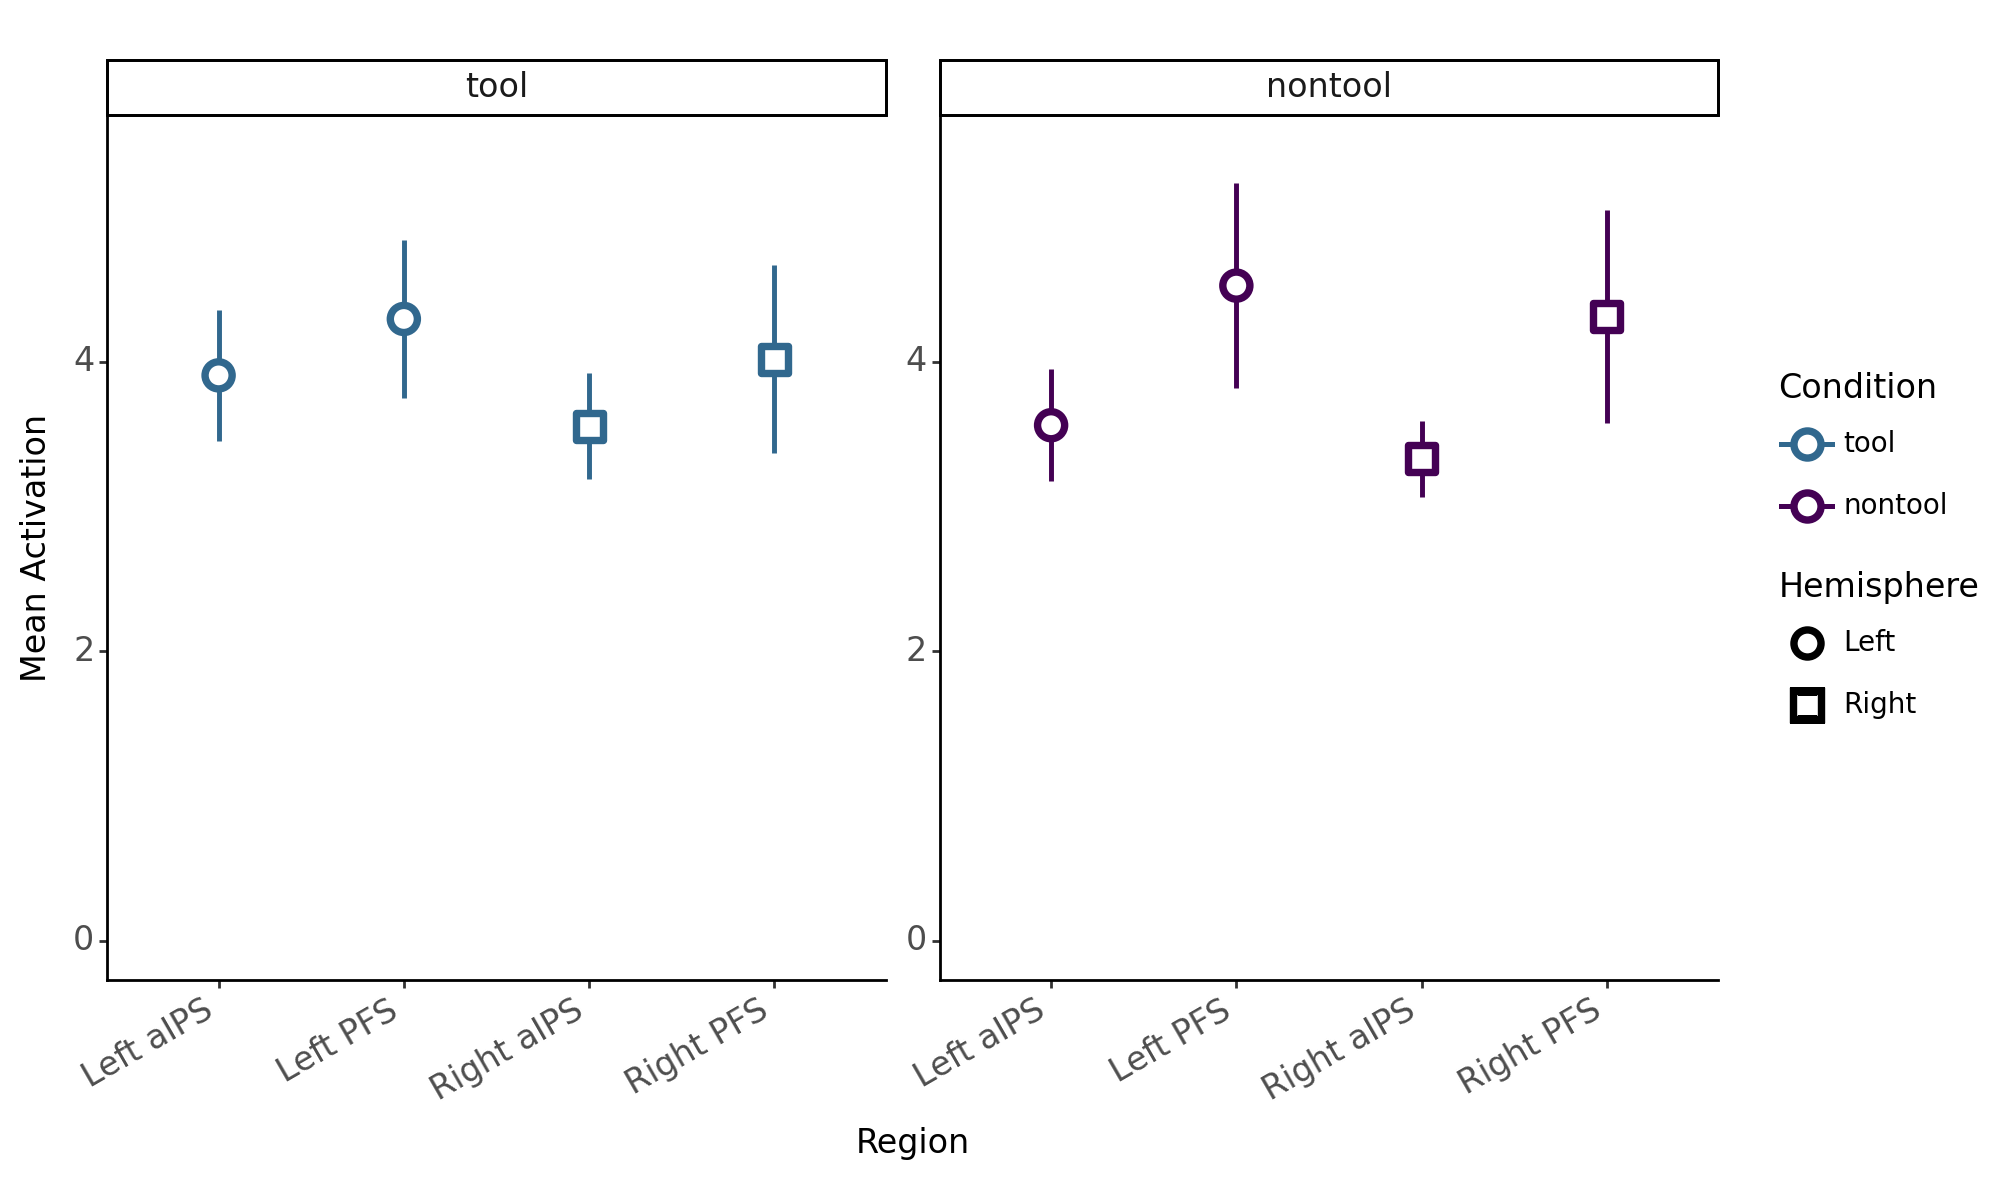

In [39]:
# plot tool and nontool conditions on the same plot
import pandas as pd
import numpy as np
from plotnine import (ggplot, aes, geom_point, geom_linerange, theme_classic, labs,
                      scale_color_manual, scale_shape_manual, theme, element_text, 
                      element_line, element_blank, coord_cartesian, scale_x_discrete, 
                      facet_wrap, guides, guide_legend)

# Read the CSV data with updated path
data = pd.read_csv("/user_data/csimmon2/git_repos/ptoc/results/tools/selectivity/selectivity_summarytoolloc.csv")

# Filter data for spaceloc subjects and relevant ROIs
filtered_data = data[(data['sub'].str.contains('spaceloc')) &
                     (data['roi'].isin(['PFS', 'aIPS'])) &
                     (data['hemi'].isin(['left', 'right']))]

# Calculate mean activation and standard deviation for each combination
summary_df = filtered_data.groupby(['hemi', 'roi', 'cond'])['mean_act'].agg(['mean', 'std', 'count']).reset_index()
summary_df['sem'] = summary_df['std'] / np.sqrt(summary_df['count'])

# Rename columns for clarity
summary_df.columns = ['Hemisphere', 'ROI', 'Condition', 'Mean', 'Std', 'Count', 'SE']

# Create more readable labels
summary_df['ROI'] = summary_df['ROI'].map({'PFS': 'PFS', 'aIPS': 'aIPS'})
summary_df['Hemisphere'] = summary_df['Hemisphere'].map({'left': 'Left', 'right': 'Right'})
summary_df['Region'] = summary_df['Hemisphere'] + ' ' + summary_df['ROI']

# Create a custom order for the x-axis
summary_df['Region_order'] = pd.Categorical(summary_df['Region'],
                                            categories=['Left aIPS', 'Left PFS', 'Right aIPS', 'Right PFS'],
                                            ordered=True)

# Sort conditions to put tool first
summary_df['Condition'] = pd.Categorical(summary_df['Condition'], ['tool', 'nontool'])

# Function to create plot
def create_plot(data):
    plot = (ggplot(data, aes(x='Region_order', y='Mean', color='Condition', shape='Hemisphere'))
            + geom_linerange(aes(ymin='Mean-Std', ymax='Mean+Std'), size=1)
            + geom_point(size=4, fill='white', stroke=1.5)
            + theme_classic()
            + labs(x='Region', y='Mean Activation')
            + scale_color_manual(values={'tool': '#31688E', 'nontool': '#440154'})  # Updated for tool conditions
            + scale_shape_manual(values={'Left': 'o', 'Right': 's'})  # Changed Right to square for better distinction
            + theme(text=element_text(size=12),
                    axis_text_x=element_text(angle=30, hjust=1),
                    axis_line=element_line(colour="black"),
                    panel_border=element_blank(),
                    legend_position="right",
                    legend_box="vertical",
                    legend_title=element_text(size=12),
                    legend_text=element_text(size=10),
                    figure_size=(10, 6))
            + coord_cartesian(ylim=(0, data['Mean'].max() * 1.2))
            + scale_x_discrete(limits=['Left aIPS', 'Left PFS', 'Right aIPS', 'Right PFS'])
            + guides(color=guide_legend(title="Condition"),
                     shape=guide_legend(title="Hemisphere"))
            + facet_wrap('~ Condition', scales='free_y', ncol=2))
    return plot

# Create and print plot
plot = create_plot(summary_df)
print(plot)

# Save the plot with updated path
plot.save("/user_data/csimmon2/git_repos/ptoc/results/tools/selectivity/activation_plot_combined.png", dpi=300, width=10, height=6)
# rois defined by registered native parcellation

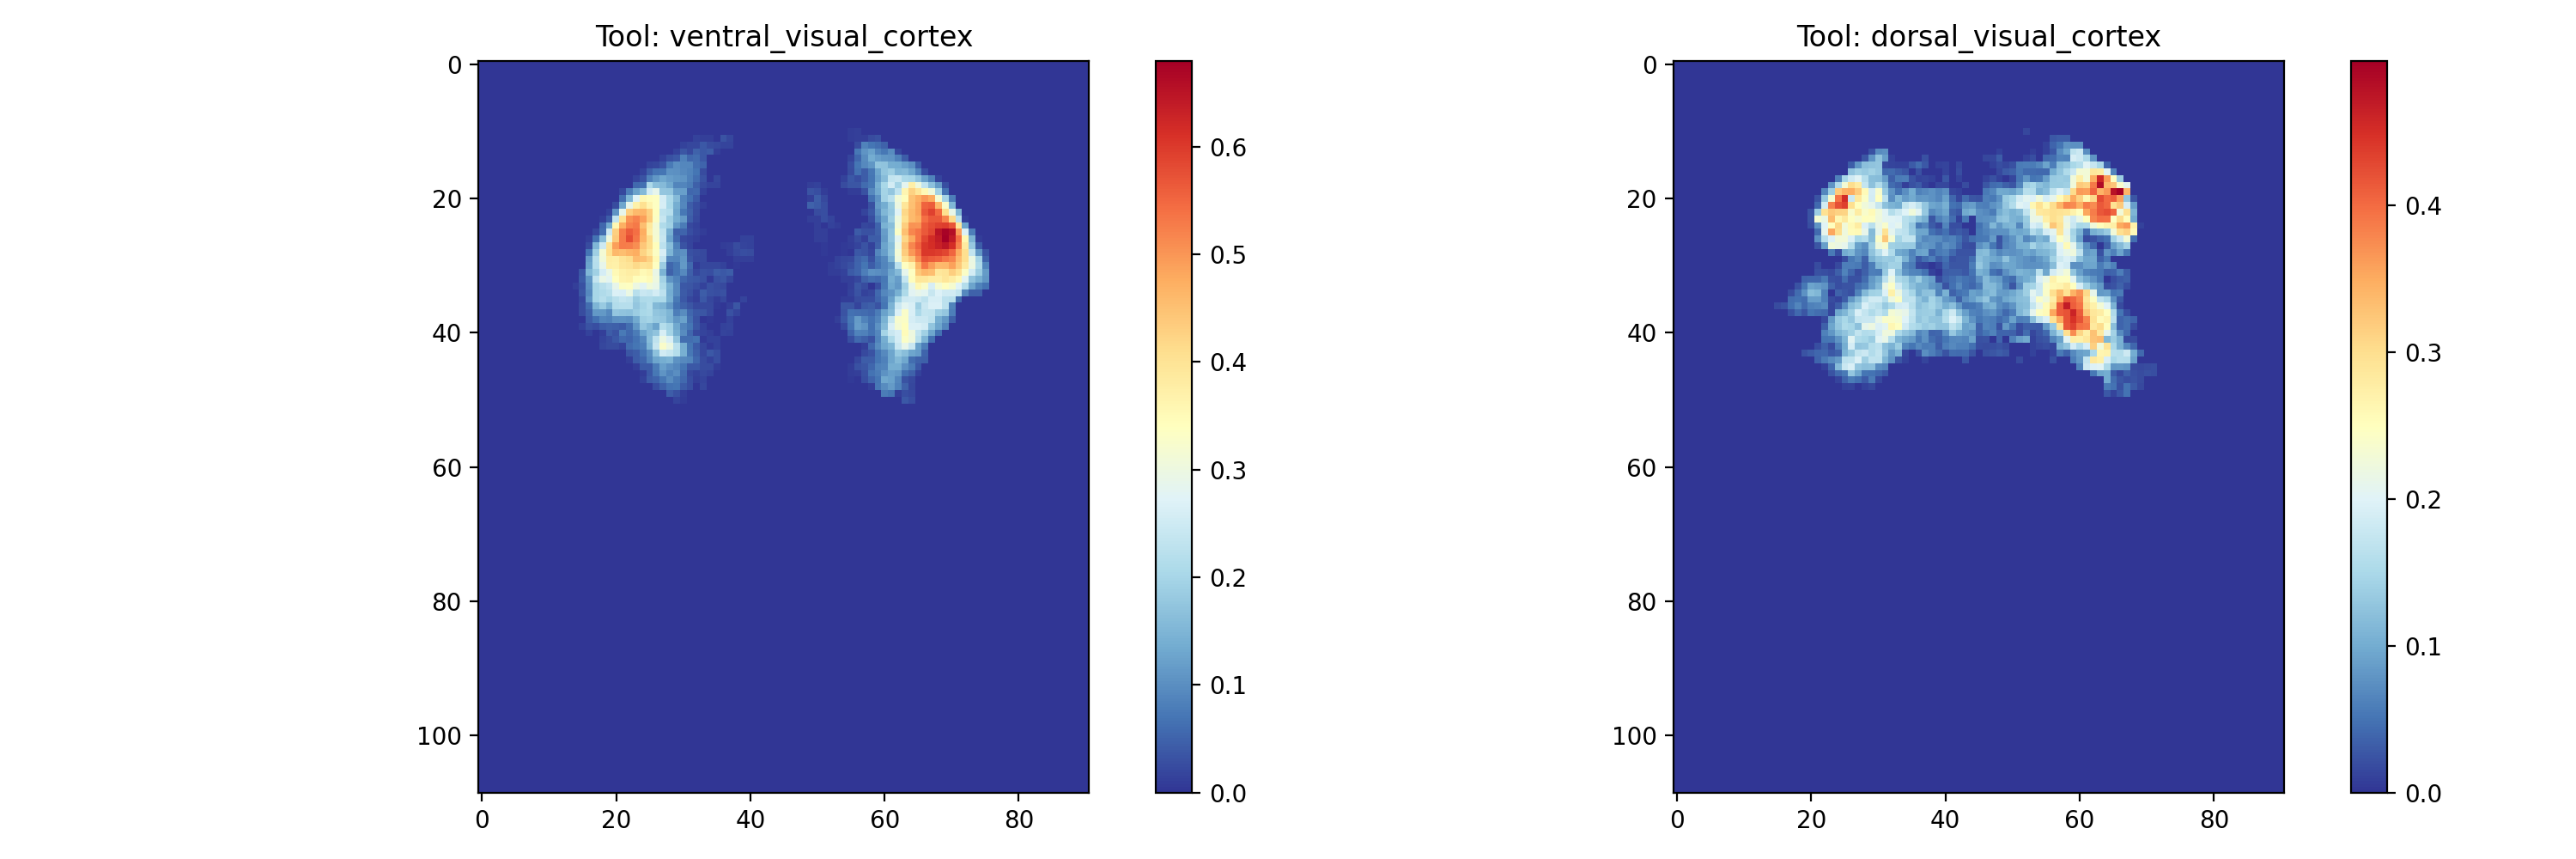

In [32]:
# plot dorsal and ventral visual cortex heat map
import sys
import matplotlib.pyplot as plt
import numpy as np

curr_dir = f'/user_data/csimmon2/git_repos/ptoc'
sys.path.insert(0,curr_dir)
import ptoc_params as params

results_dir = params.results_dir 

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

for idx, roi_type in enumerate(['ventral_visual_cortex', 'dorsal_visual_cortex']):
    data = np.load(f'{results_dir}/neural_map/{roi_type}_tool_func.npy')
    im = ax[idx].imshow(data, cmap='RdYlBu_r')
    plt.colorbar(im, ax=ax[idx])
    ax[idx].set_title(f'Tool: {roi_type}')

plt.tight_layout()
plt.show()

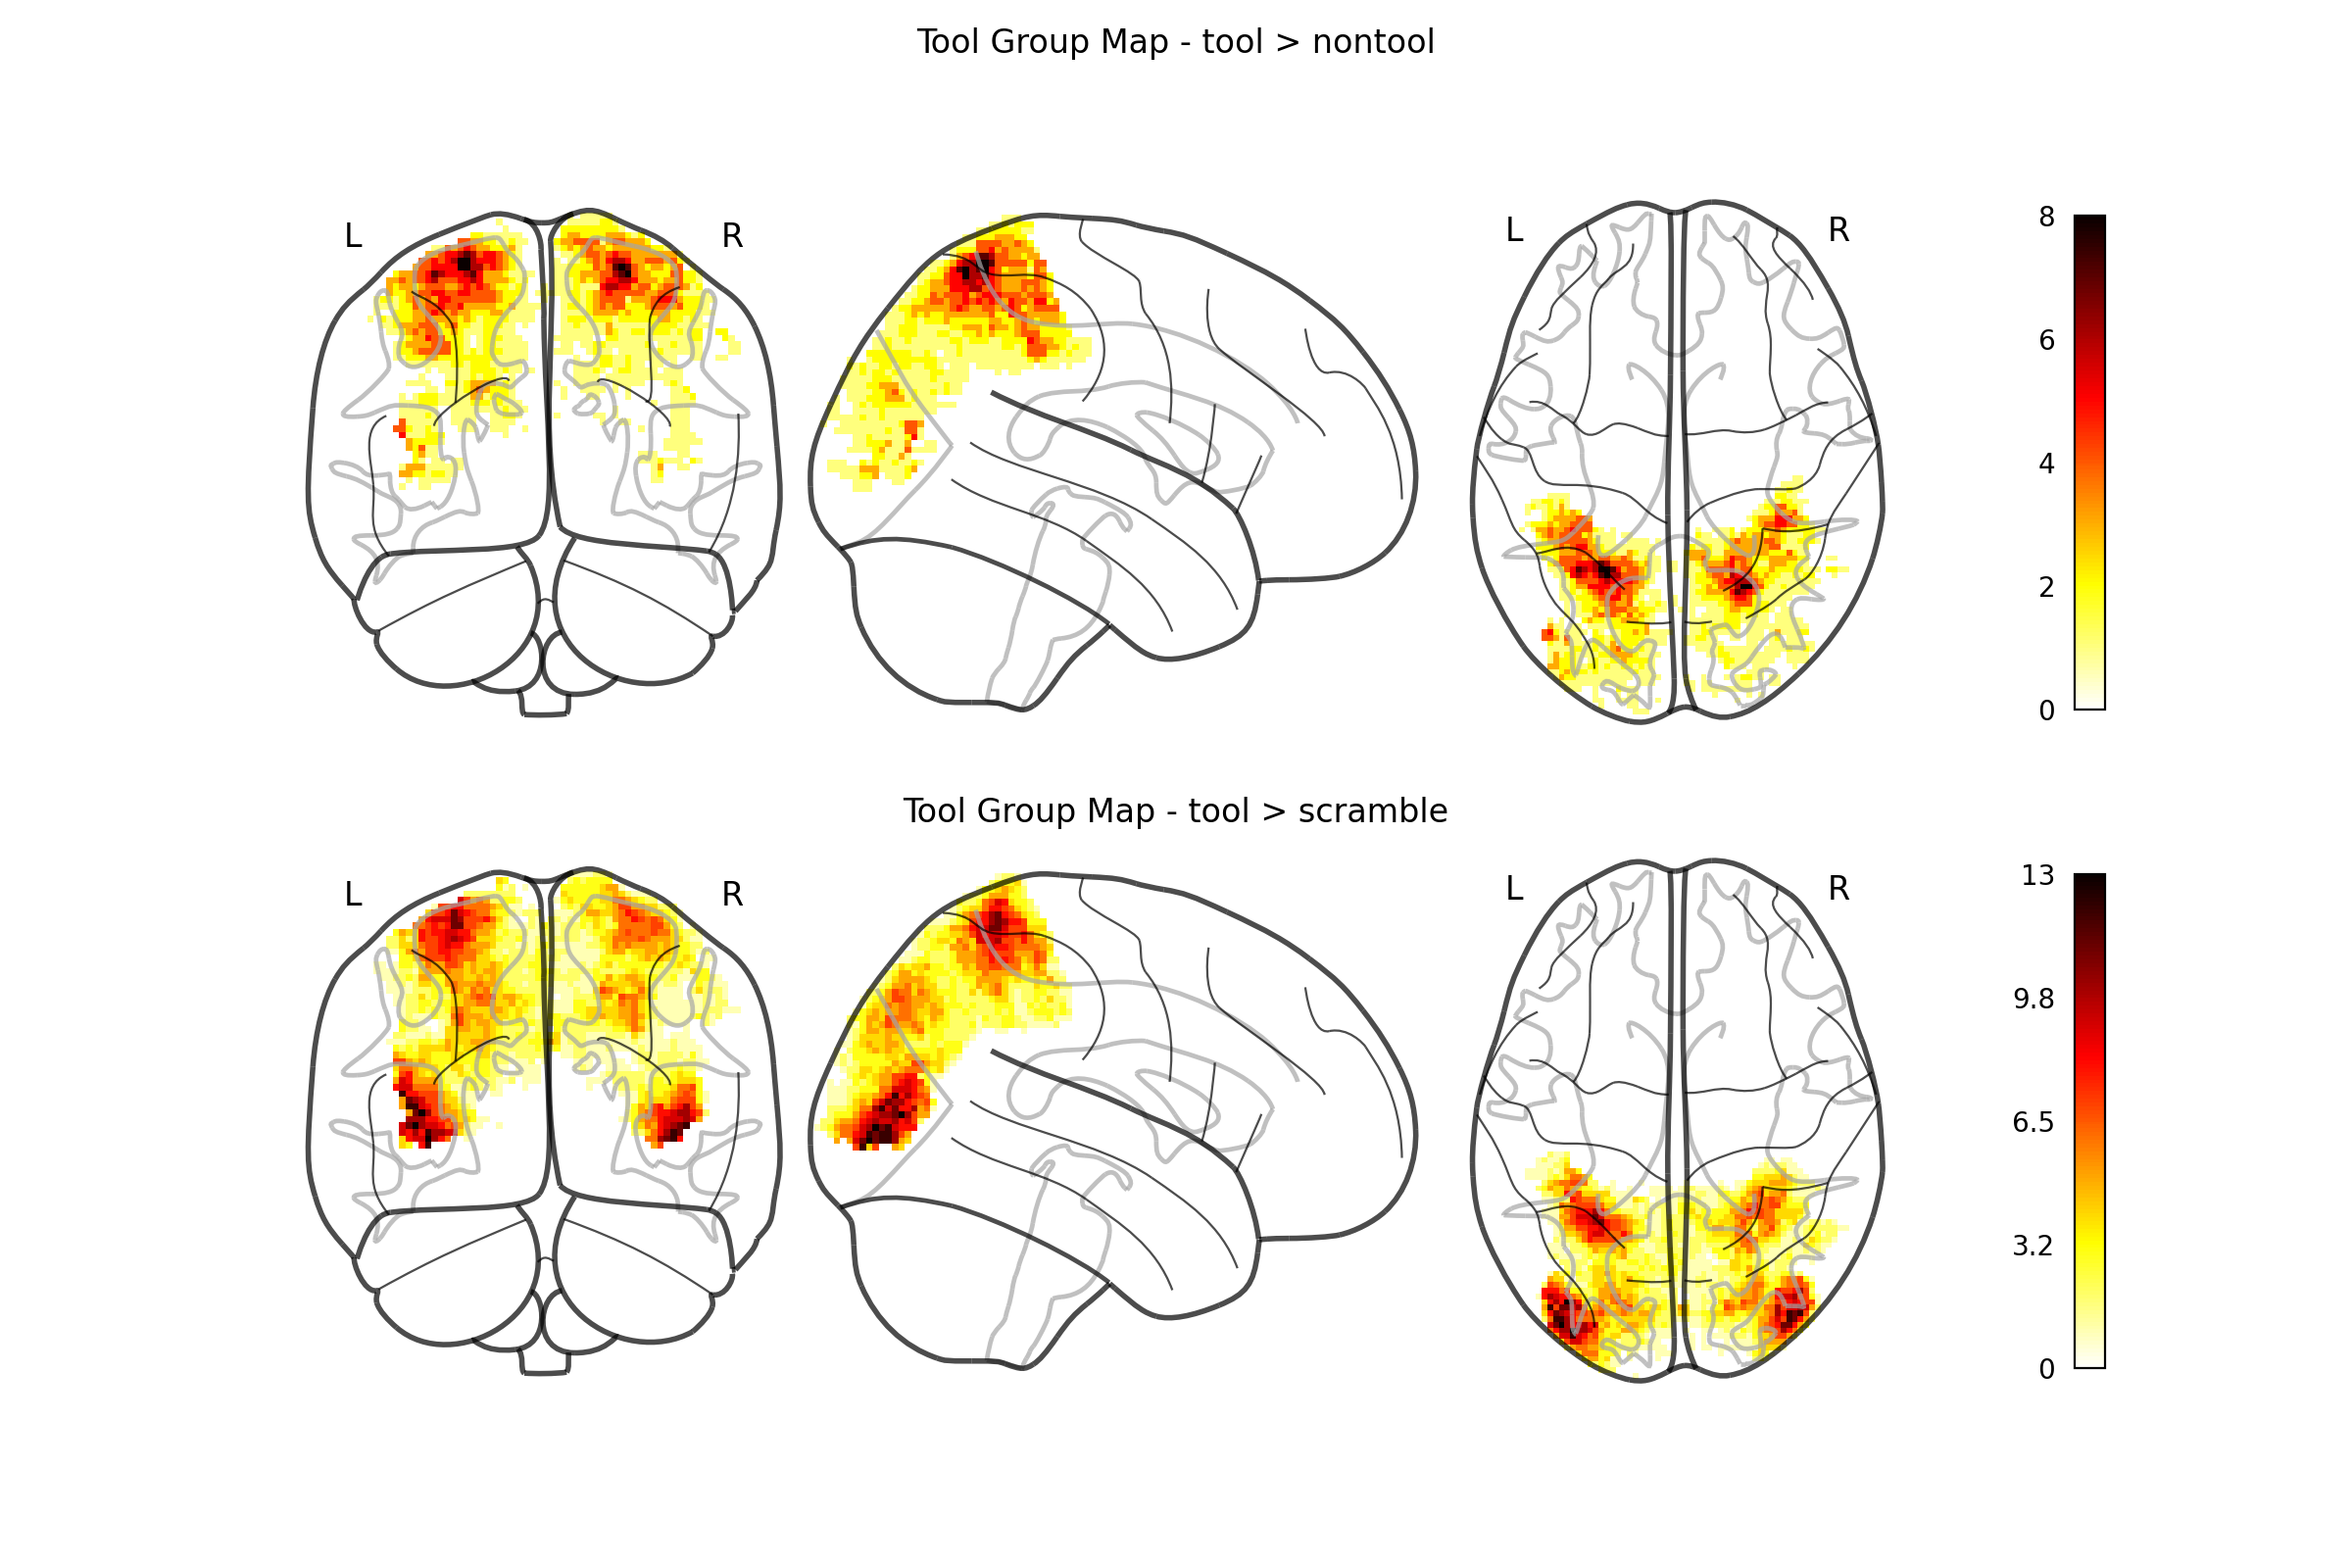

In [36]:
# plot zstat maps for tool condition
import sys
curr_dir = f'/user_data/csimmon2/git_repos/ptoc'
sys.path.insert(0,curr_dir)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import itertools
from nilearn import image, plotting, datasets
from nilearn.datasets import load_mni152_brain_mask, load_mni152_template
import nibabel as nib
import os
import ptoc_params as params
import warnings
warnings.filterwarnings("ignore")

# Paths and parameters
raw_dir = params.raw_dir
results_dir = params.results_dir
fig_dir = params.fig_dir
sub_info = params.sub_info_tool[params.sub_info_tool['exp'] == 'spaceloc']
task_info = params.task_info
thresh = 0
suf = params.suf
mni = load_mni152_brain_mask()
roi_dir = '/user_data/csimmon2/git_repos/ptoc/roiParcels'

def plot_group_maps():
   """Plot group maps for tool condition with different cope levels"""
   # Load group maps for cope 1 and cope 3
   group_nii_cope3 = image.load_img(f'{results_dir}/neural_map/tool_group.nii.gz')
   group_nii_cope1 = image.load_img(f'{results_dir}/neural_map/toolnontool_group.nii.gz')
   
   # Create figure with two subplots 
   fig, axes = plt.subplots(2, 1, figsize=(12, 8))
   
   # Plot cope 1
   display1 = plotting.plot_glass_brain(group_nii_cope1, colorbar=True, plot_abs=False, 
                                      threshold=0, figure=fig, axes=axes[0])
   axes[0].set_title('Tool Group Map - tool > nontool')
   
   # Plot cope 3
   display2 = plotting.plot_glass_brain(group_nii_cope3, colorbar=True, plot_abs=False,
                                      threshold=0, figure=fig, axes=axes[1]) 
   axes[1].set_title('Tool Group Map - tool > scramble')
   
   plt.tight_layout()
   plt.show()

# Run plotting
plot_group_maps()

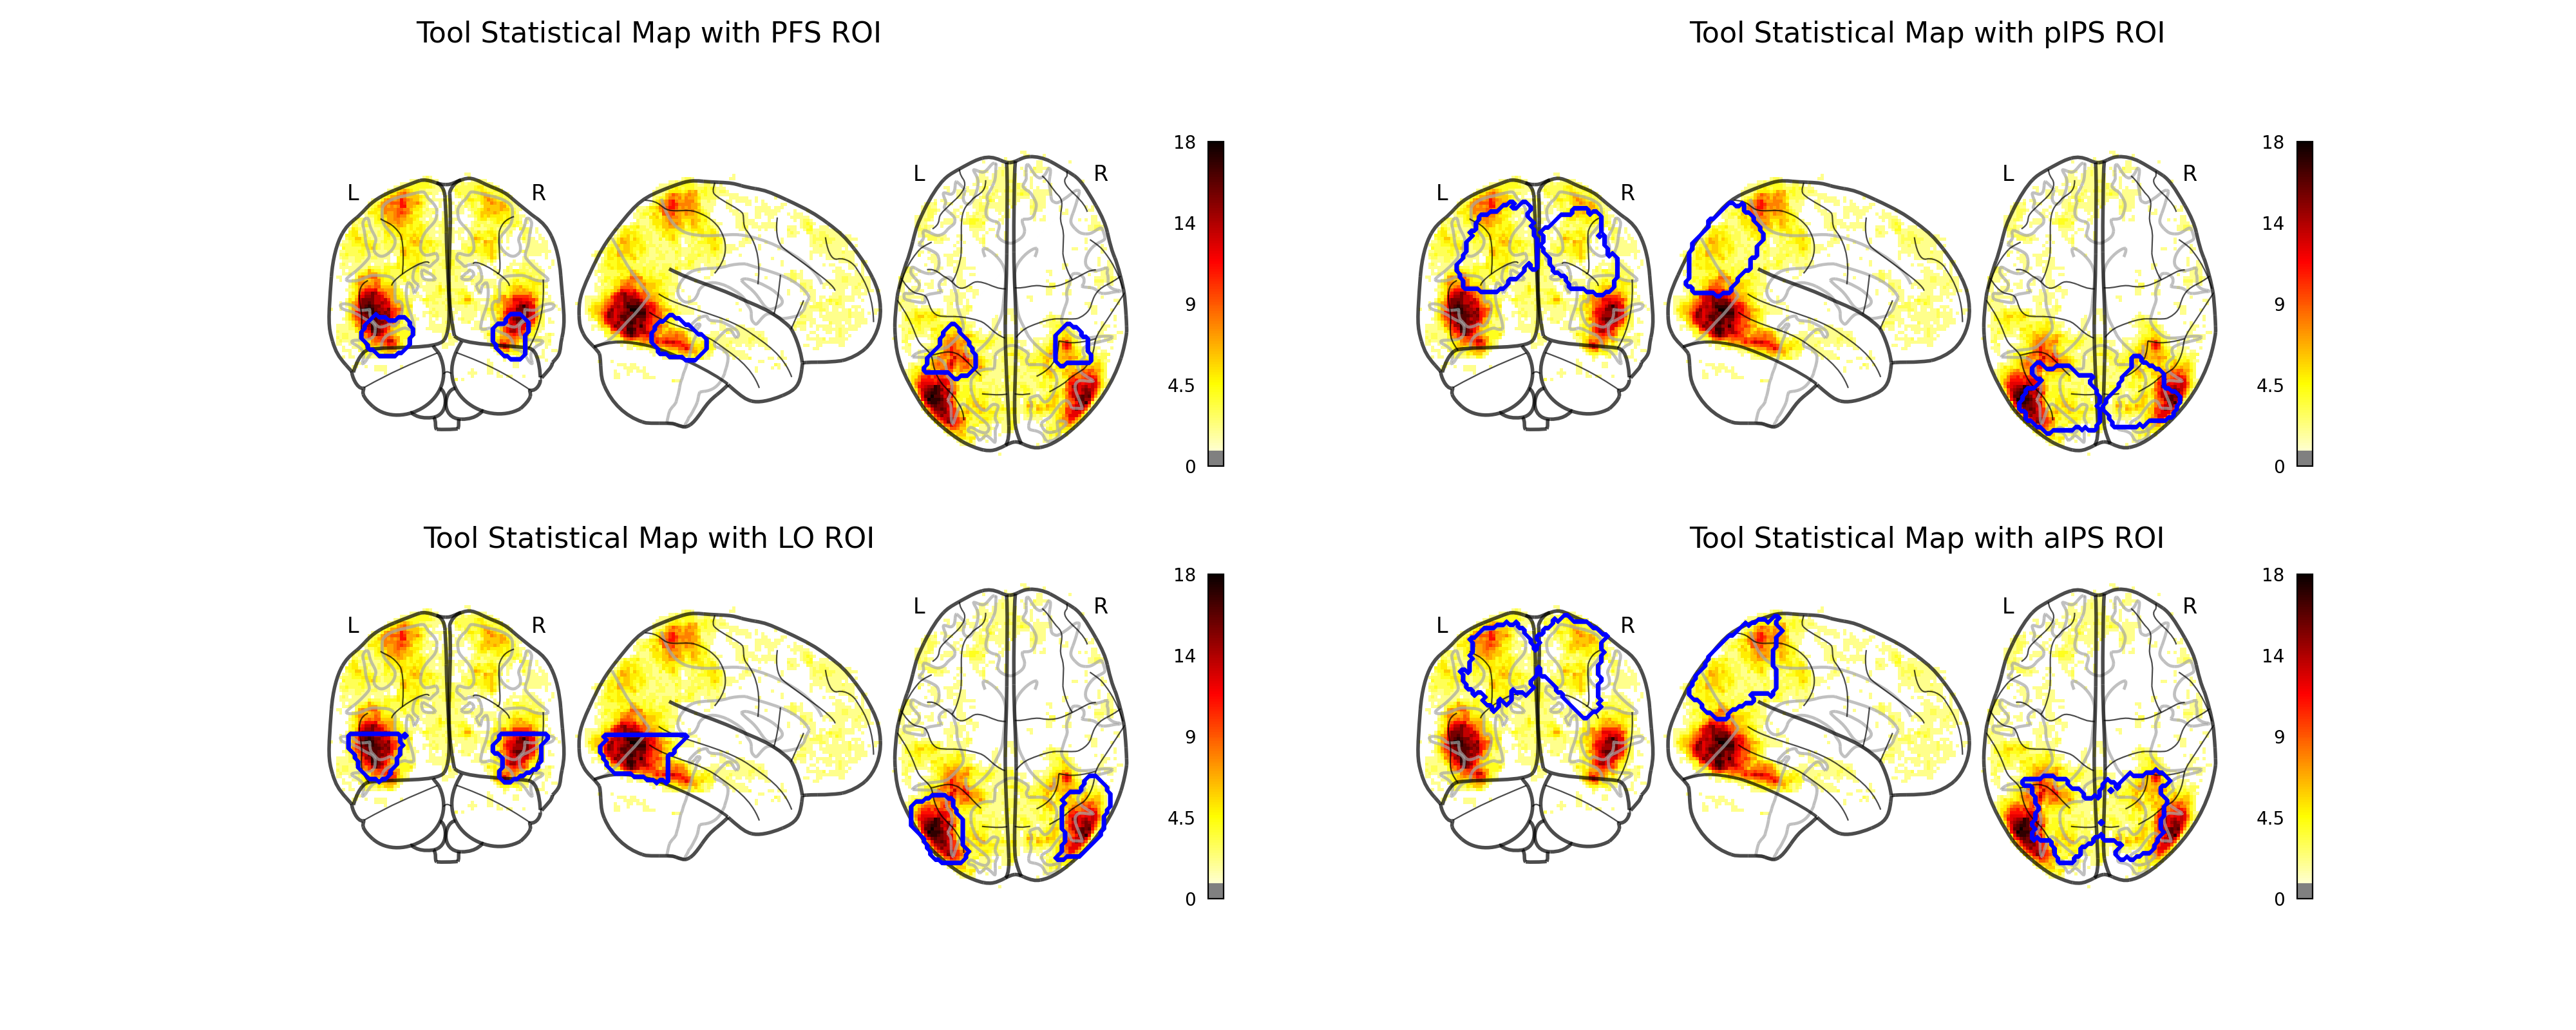

In [91]:
import matplotlib.pyplot as plt
from nilearn import plotting
import numpy as np

# Define ROIs and paths
rois = ['PFS', 'pIPS', 'LO', 'aIPS']
results_dir = '/user_data/csimmon2/git_repos/ptoc/results/tools'
roi_dir = '/user_data/csimmon2/git_repos/ptoc/roiParcels'
activation_map = f'{results_dir}/neural_map/tool_group.nii.gz'

# Create one figure with 2x2 subplots
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 8))

# Flatten axes array for easier iteration
axes_flat = axes.flatten()

# Create plots for each ROI
for idx, roi in enumerate(rois):
    roi_path = f'{roi_dir}/{roi}.nii.gz'
    
    display = plotting.plot_glass_brain(
        activation_map,
        threshold=1,
        colorbar=True,
        display_mode='ortho',
        axes=axes_flat[idx]
    )
    
    # Add ROI contour
    display.add_contours(roi_path, colors='blue', linewidths=1)
    
    # Set title with larger font size
    axes_flat[idx].title.set_text(f'Tool Statistical Map with {roi} ROI')
    axes_flat[idx].title.set_fontsize(16)

plt.tight_layout()
plt.show()

/tmp/ipykernel_9940/3768176061.py:100: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


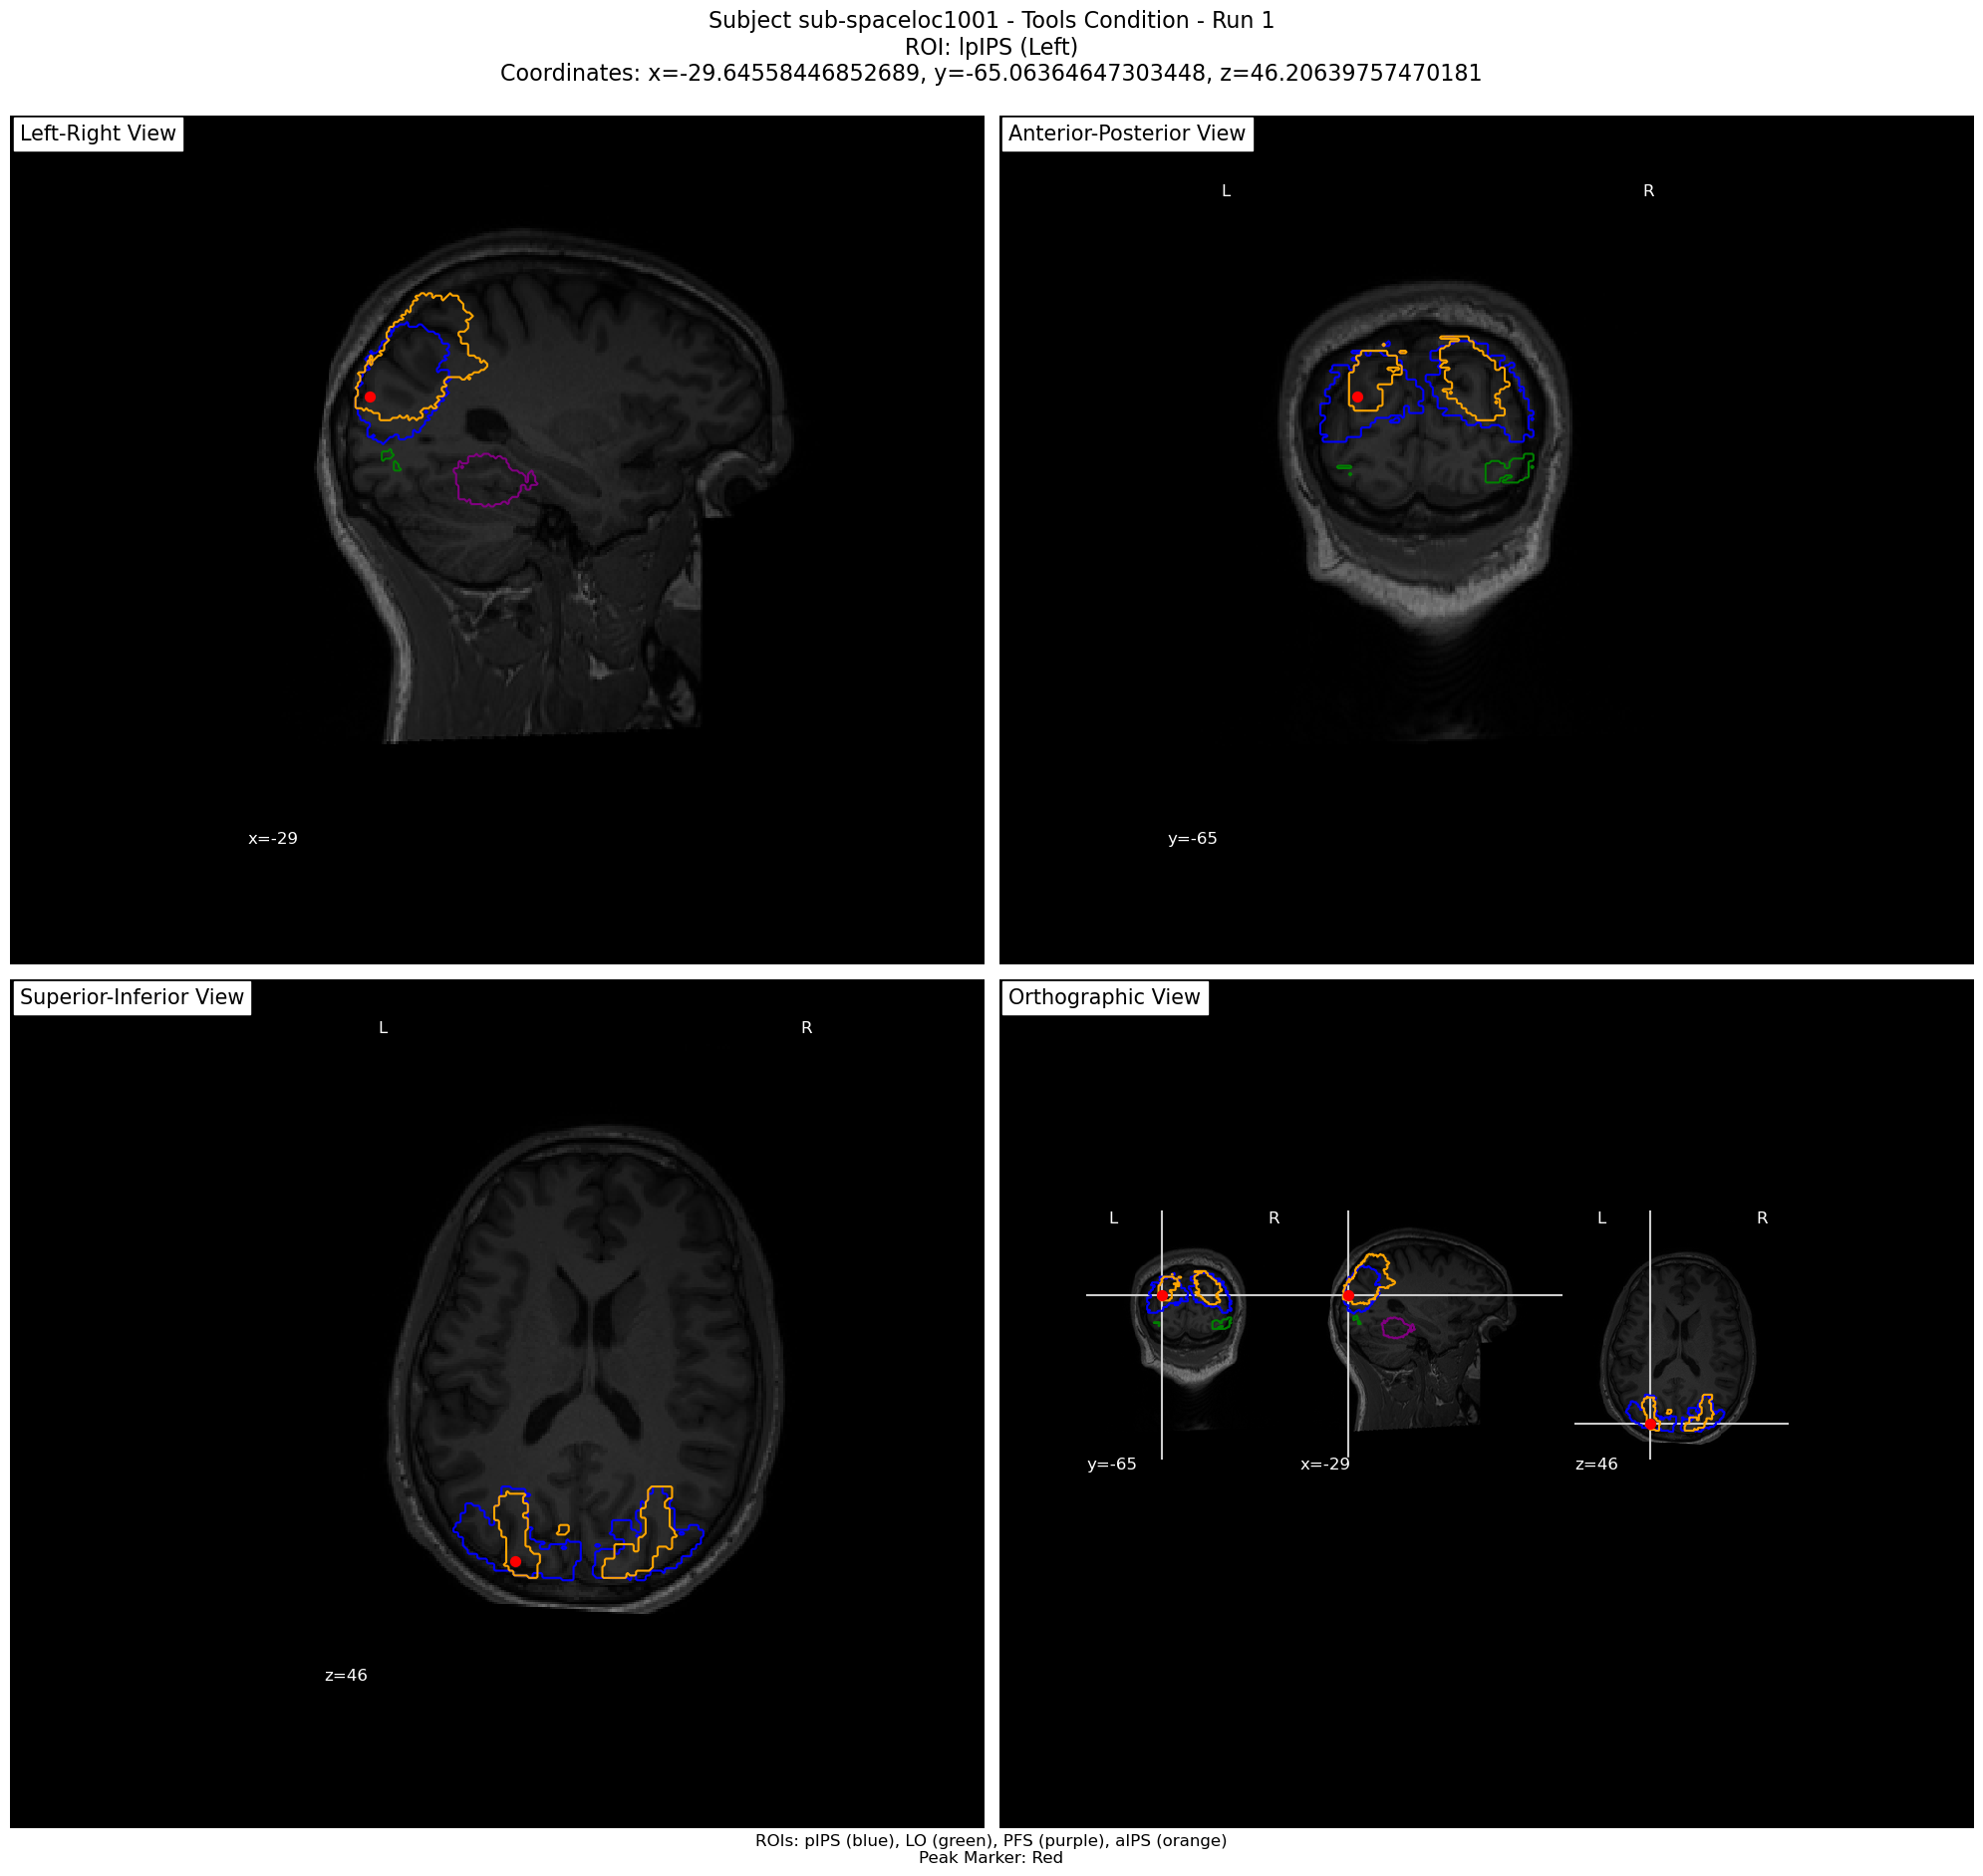

/tmp/ipykernel_9940/3768176061.py:100: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


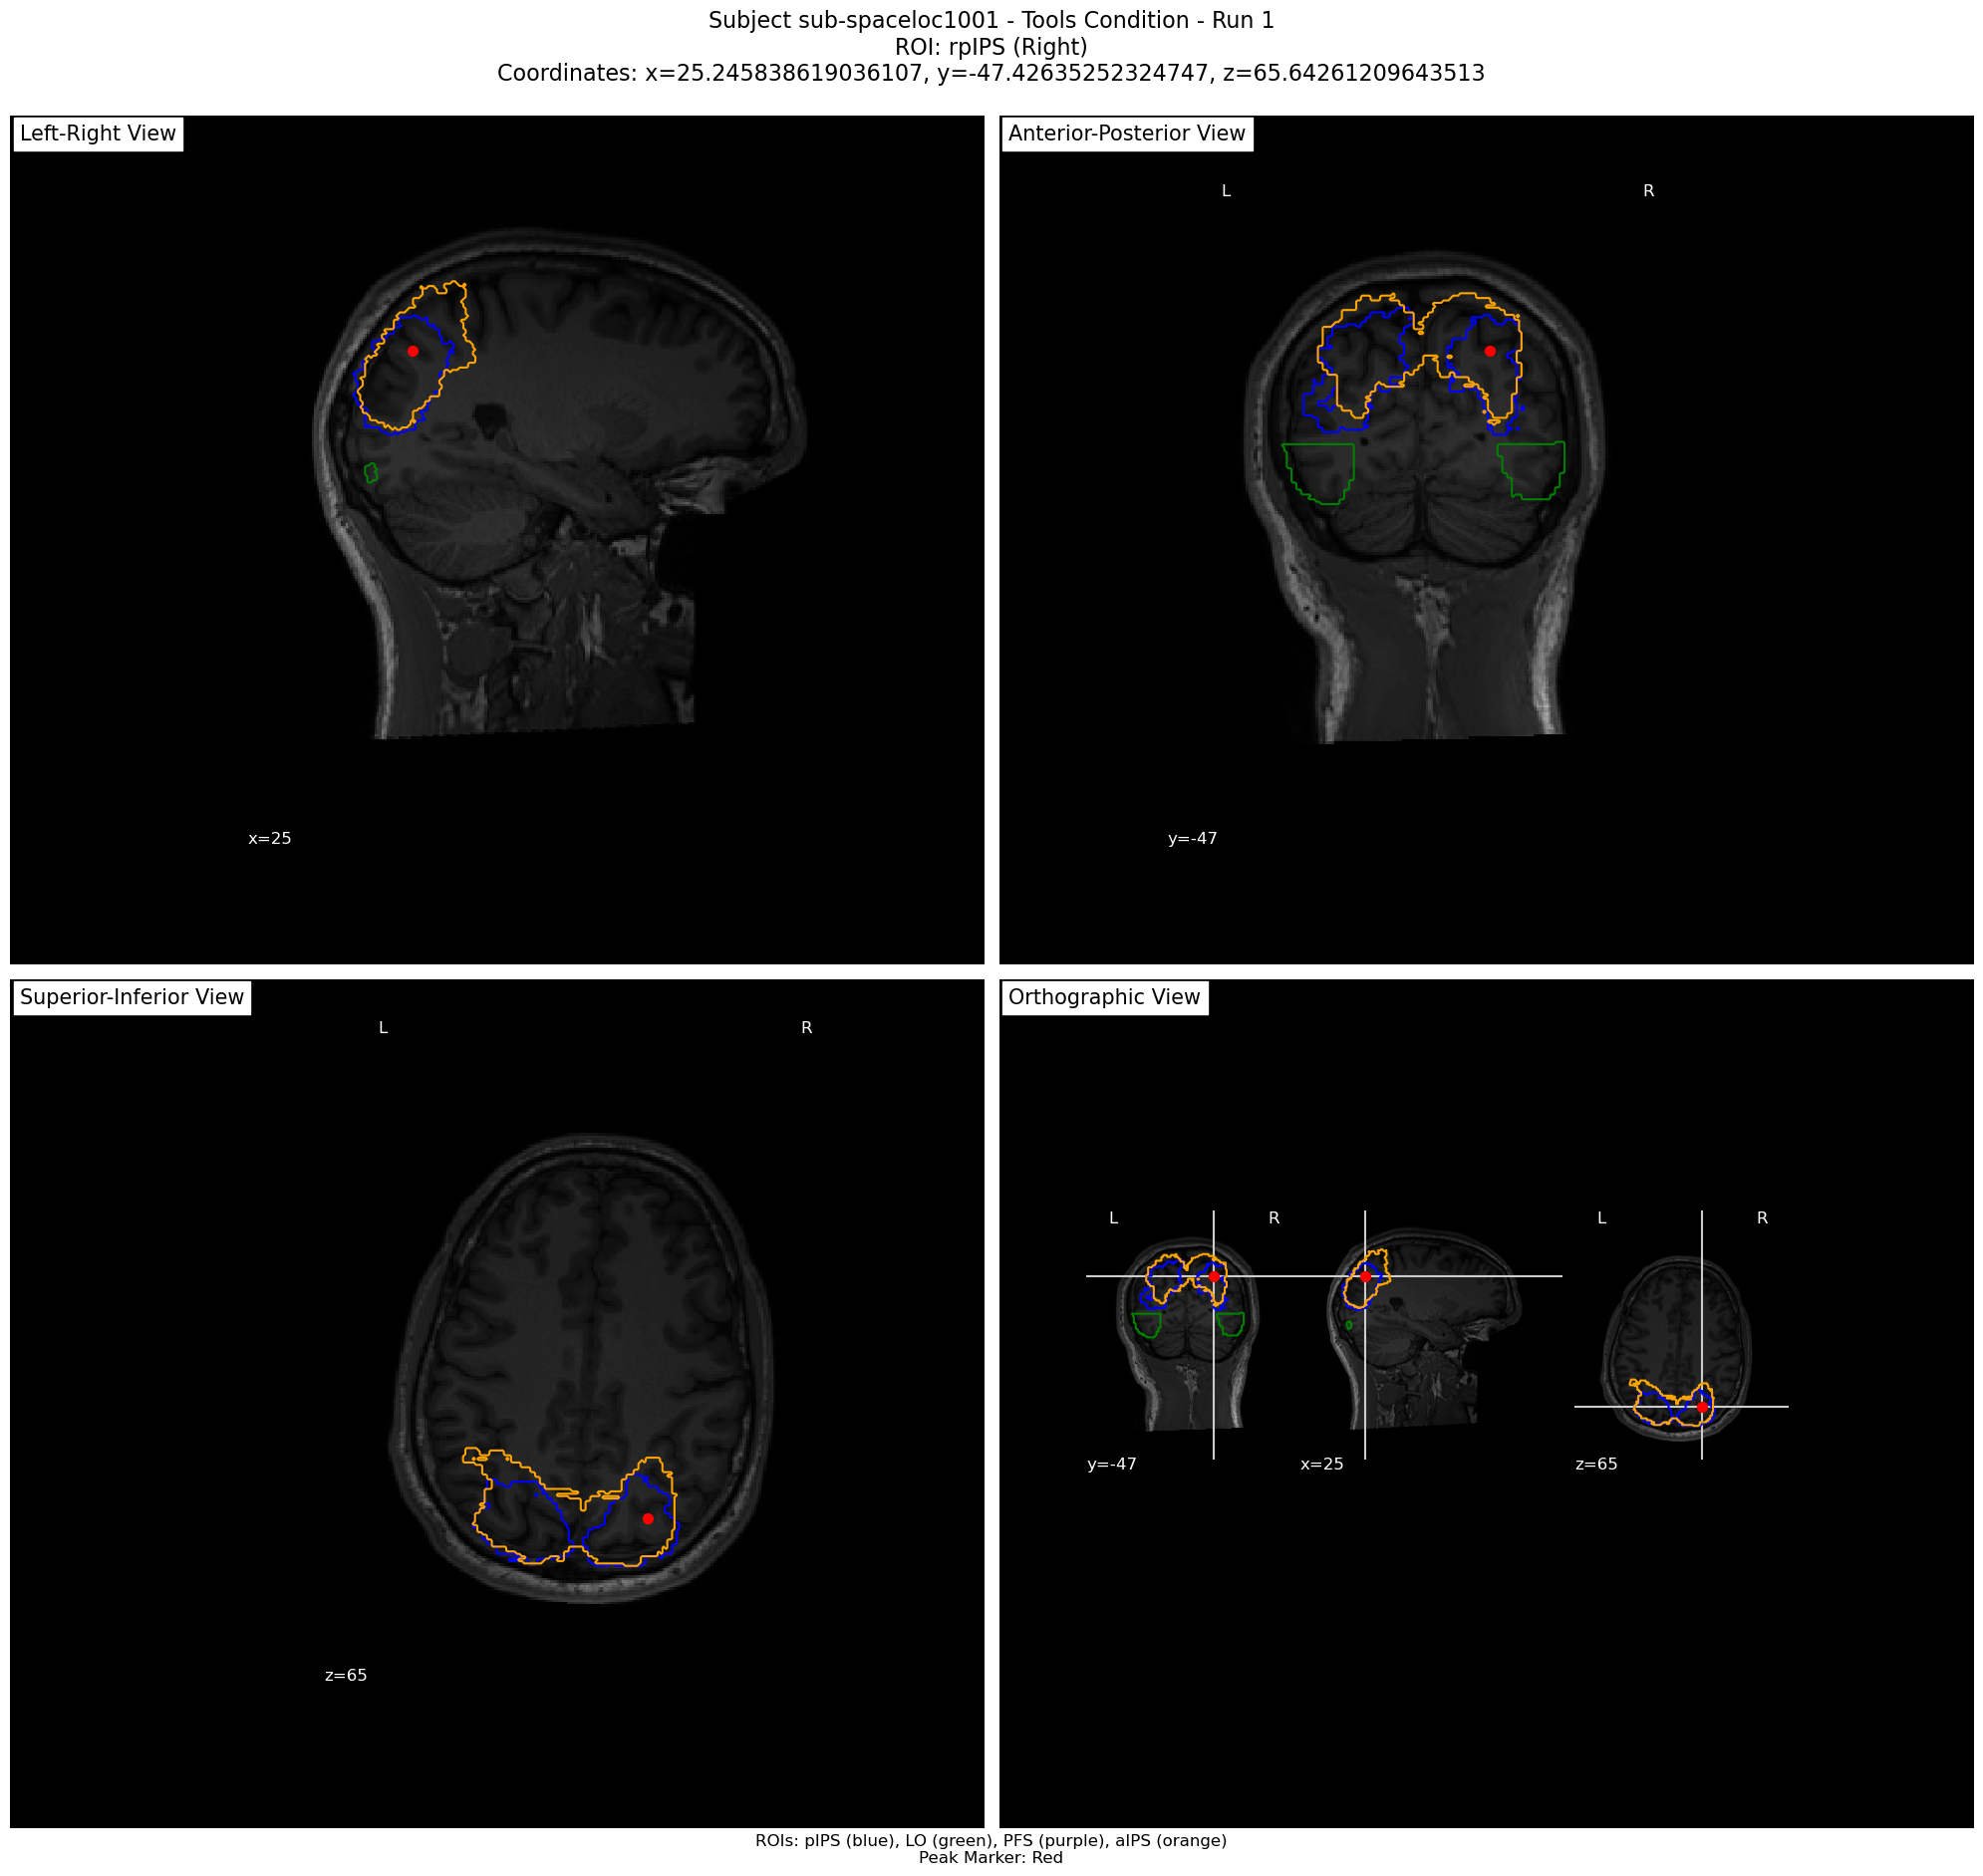

/tmp/ipykernel_9940/3768176061.py:100: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


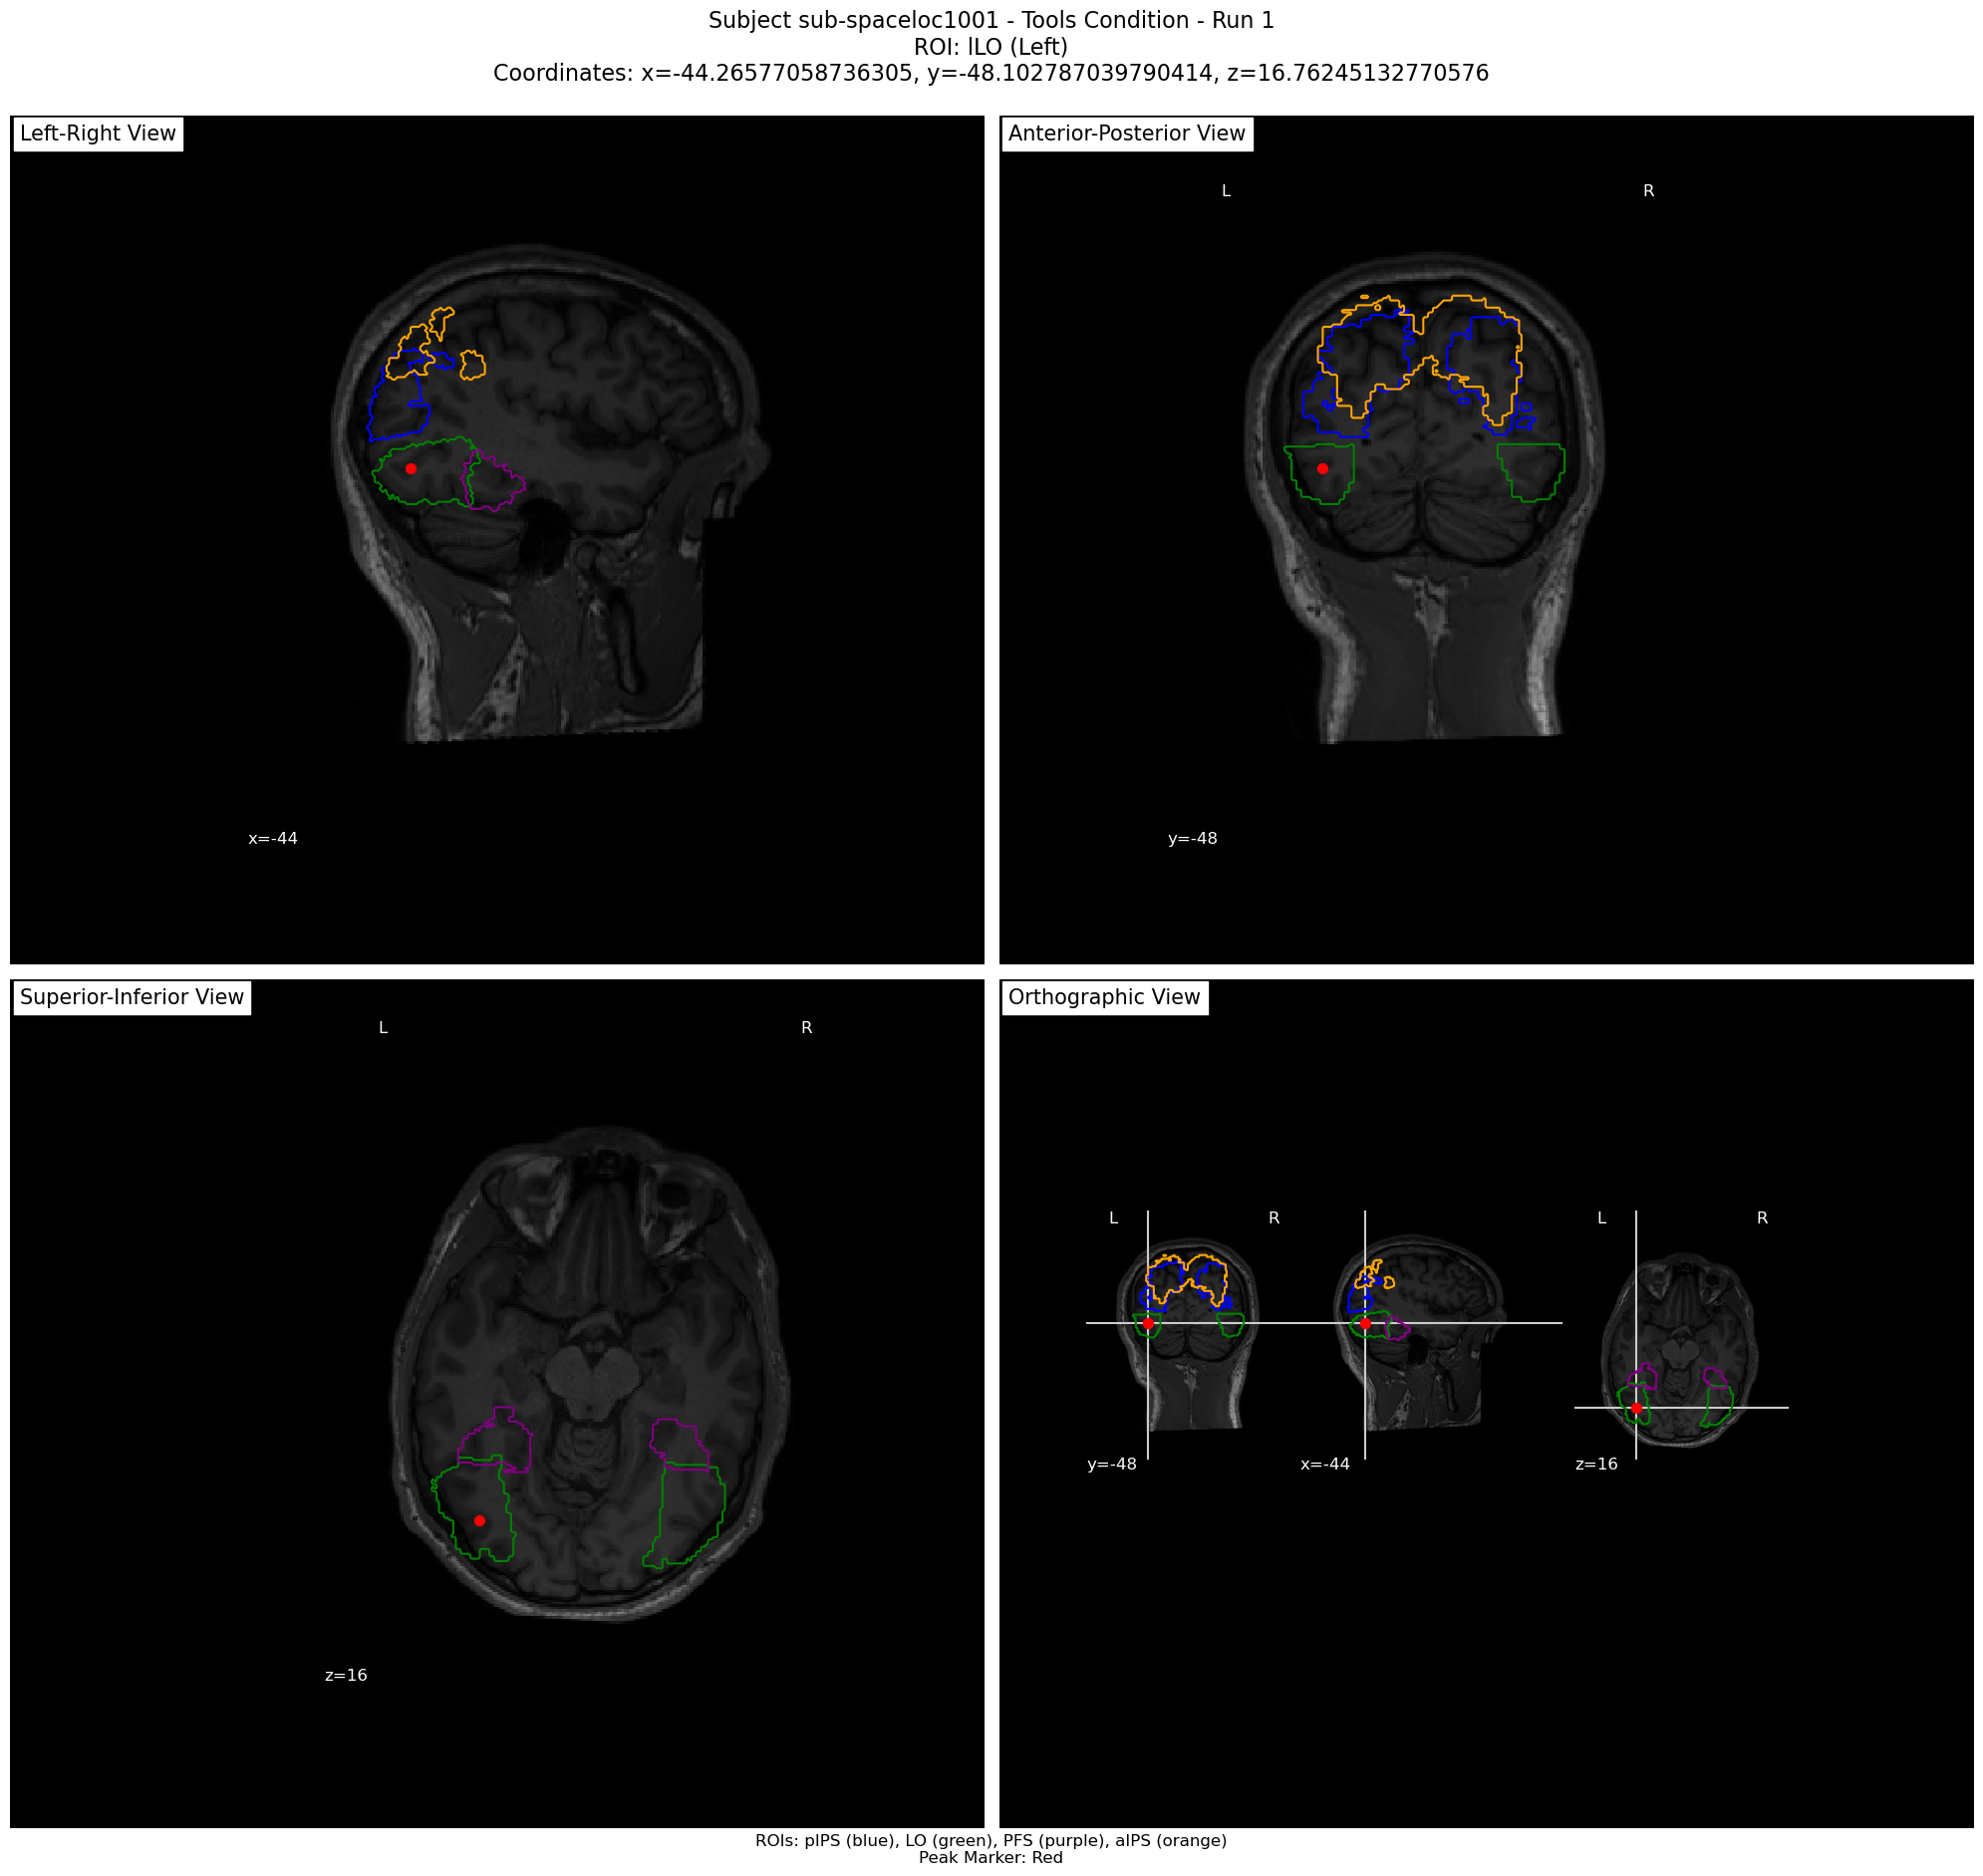

/tmp/ipykernel_9940/3768176061.py:100: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


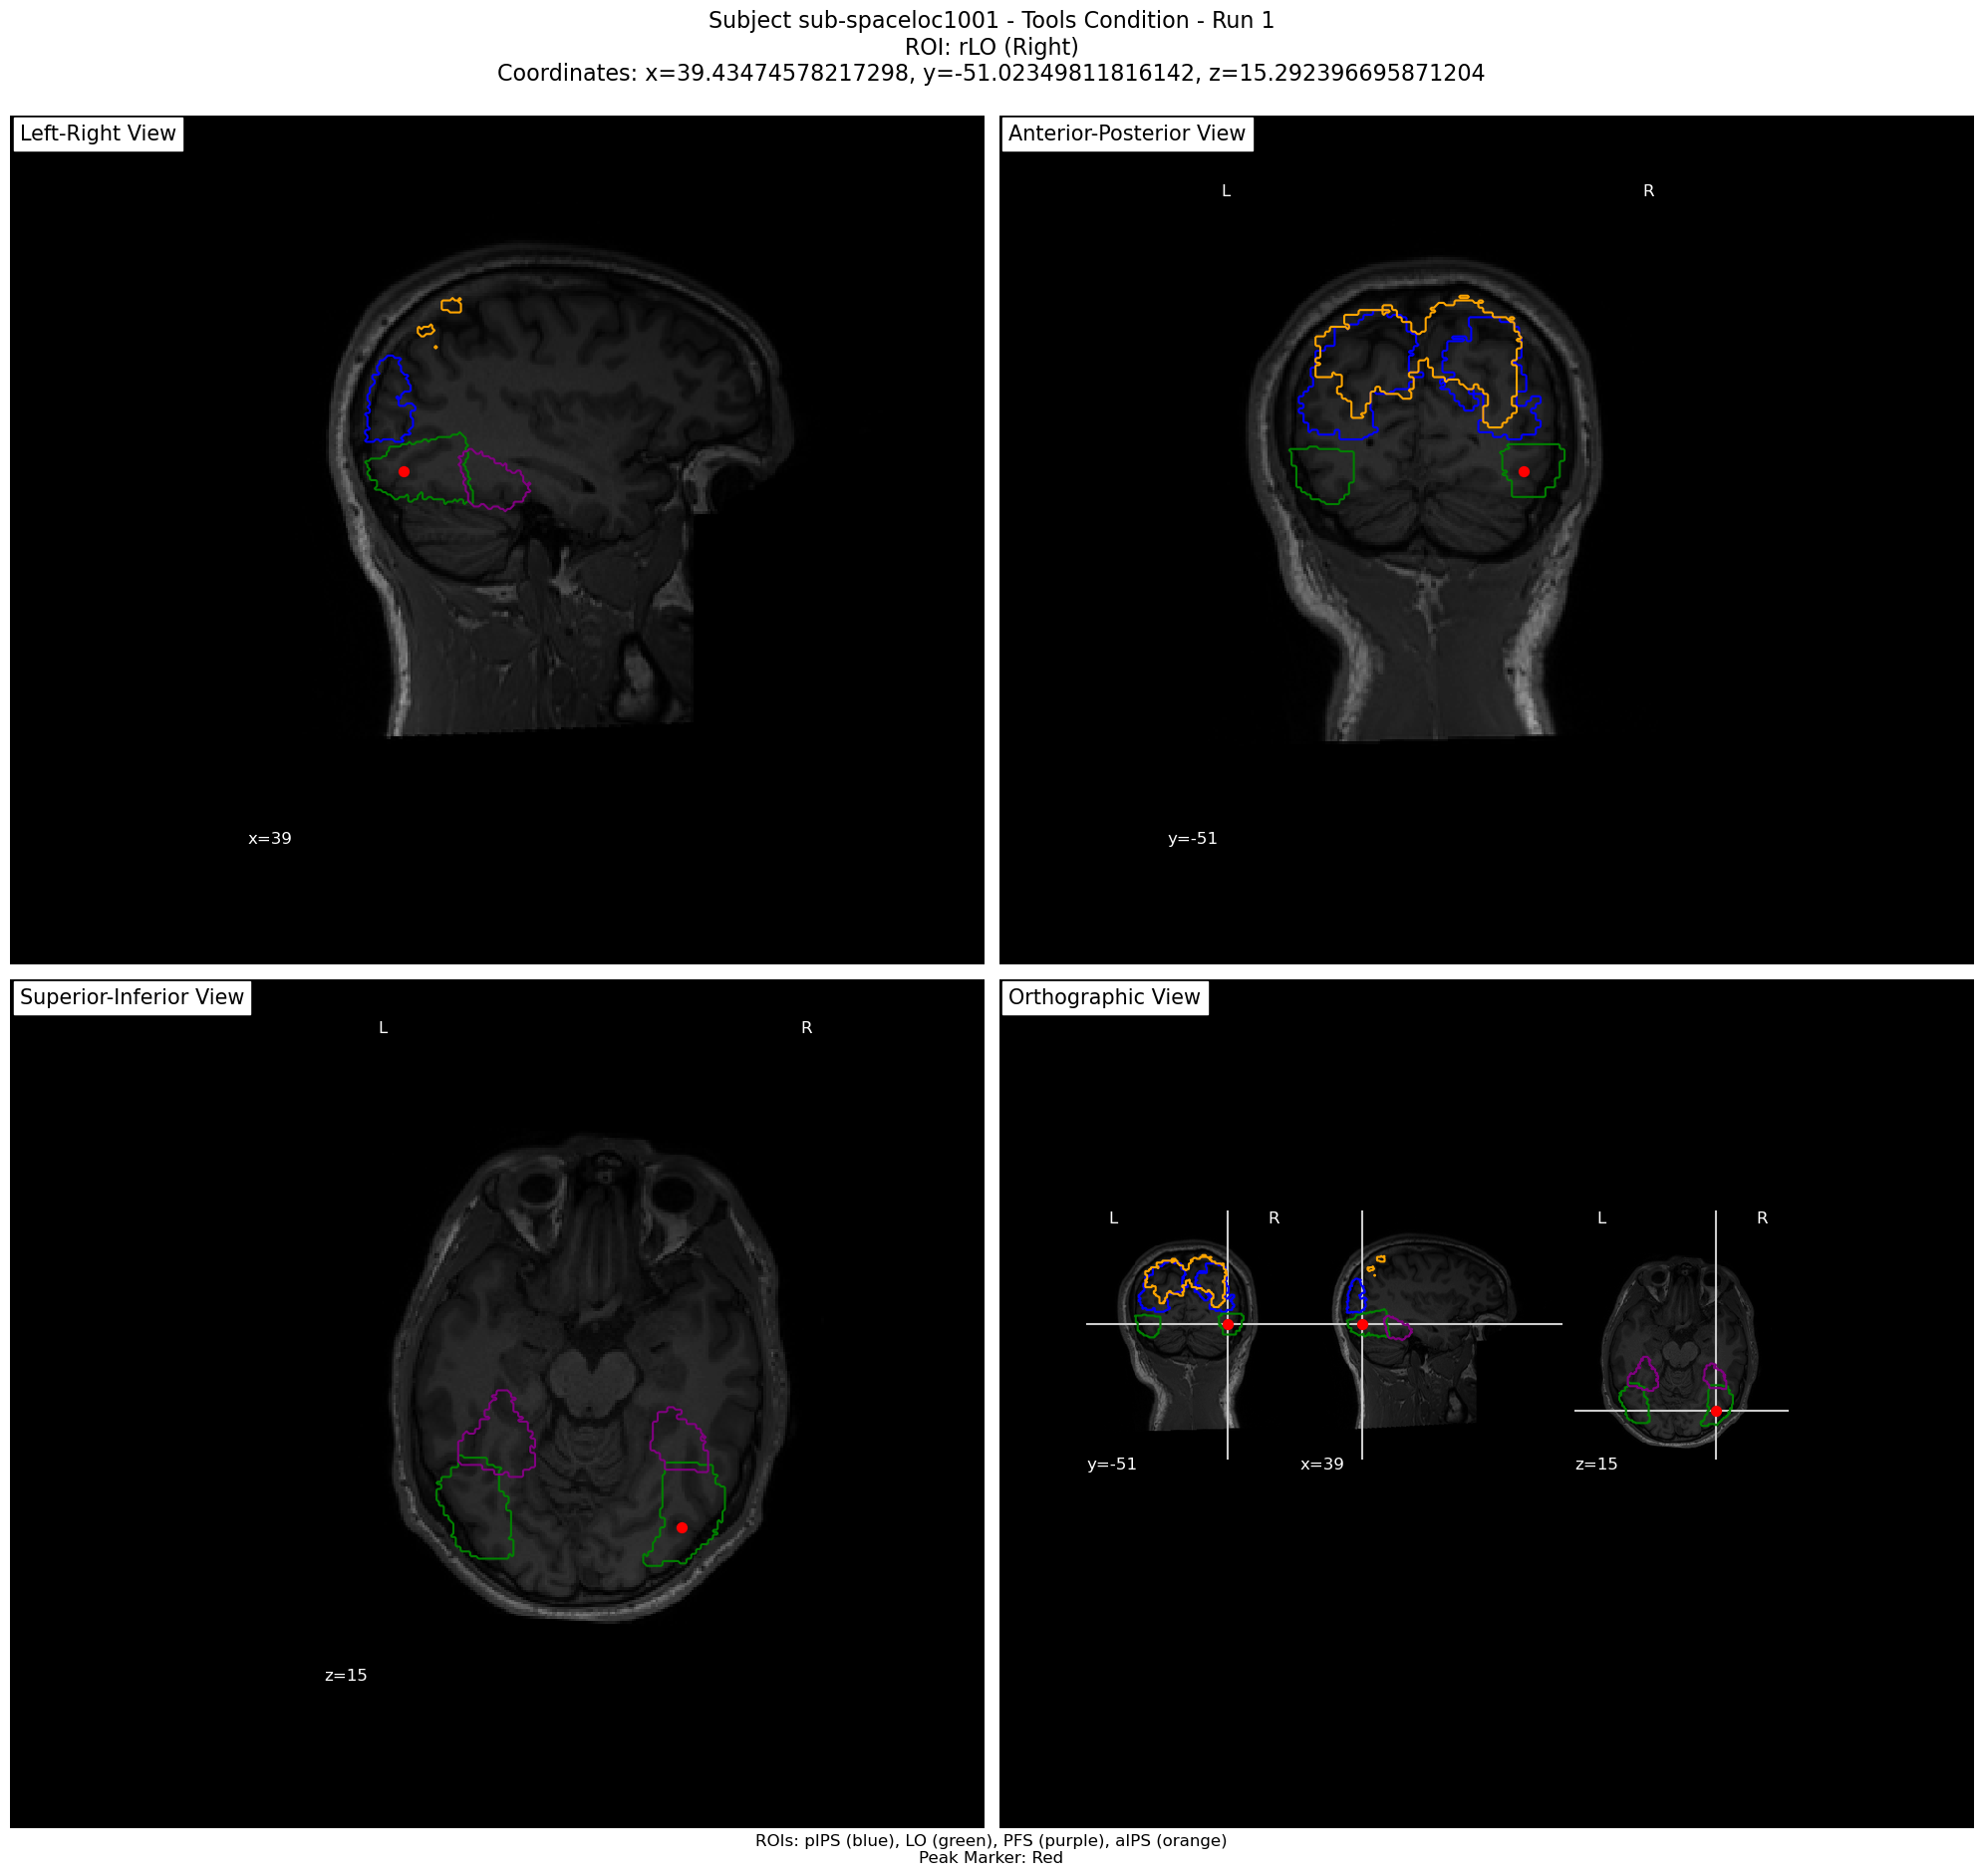

/tmp/ipykernel_9940/3768176061.py:100: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


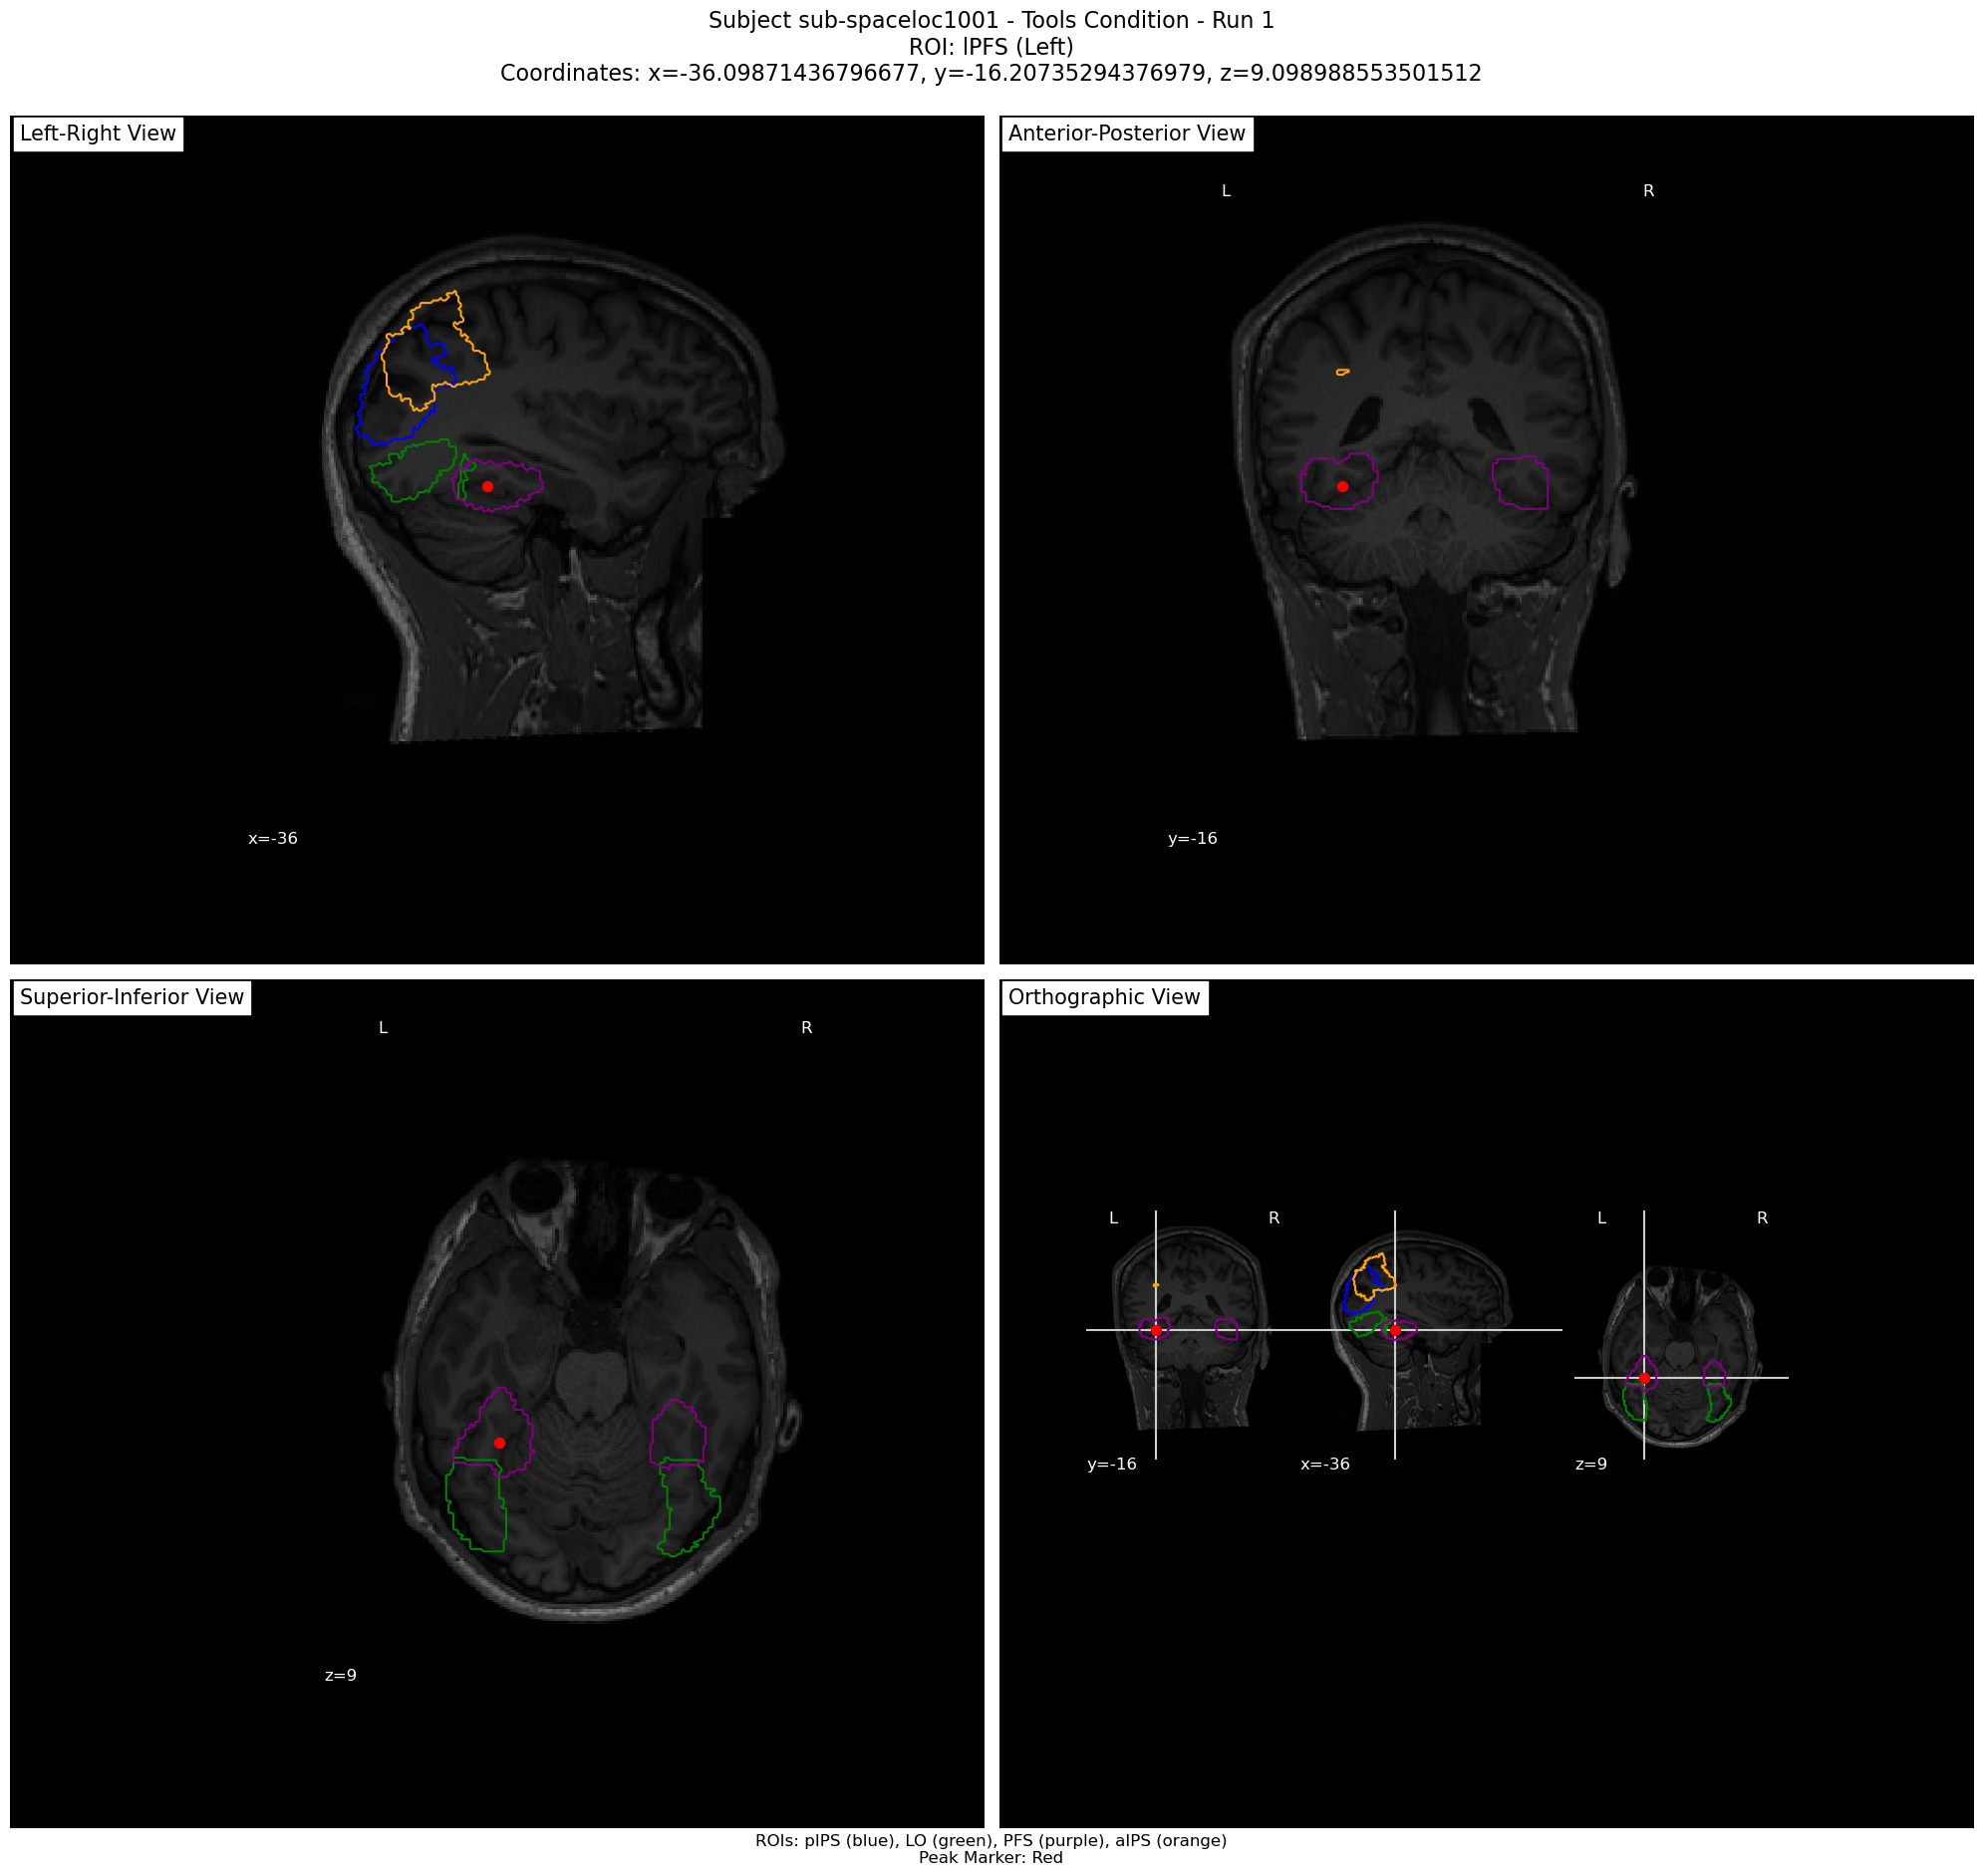

/tmp/ipykernel_9940/3768176061.py:100: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


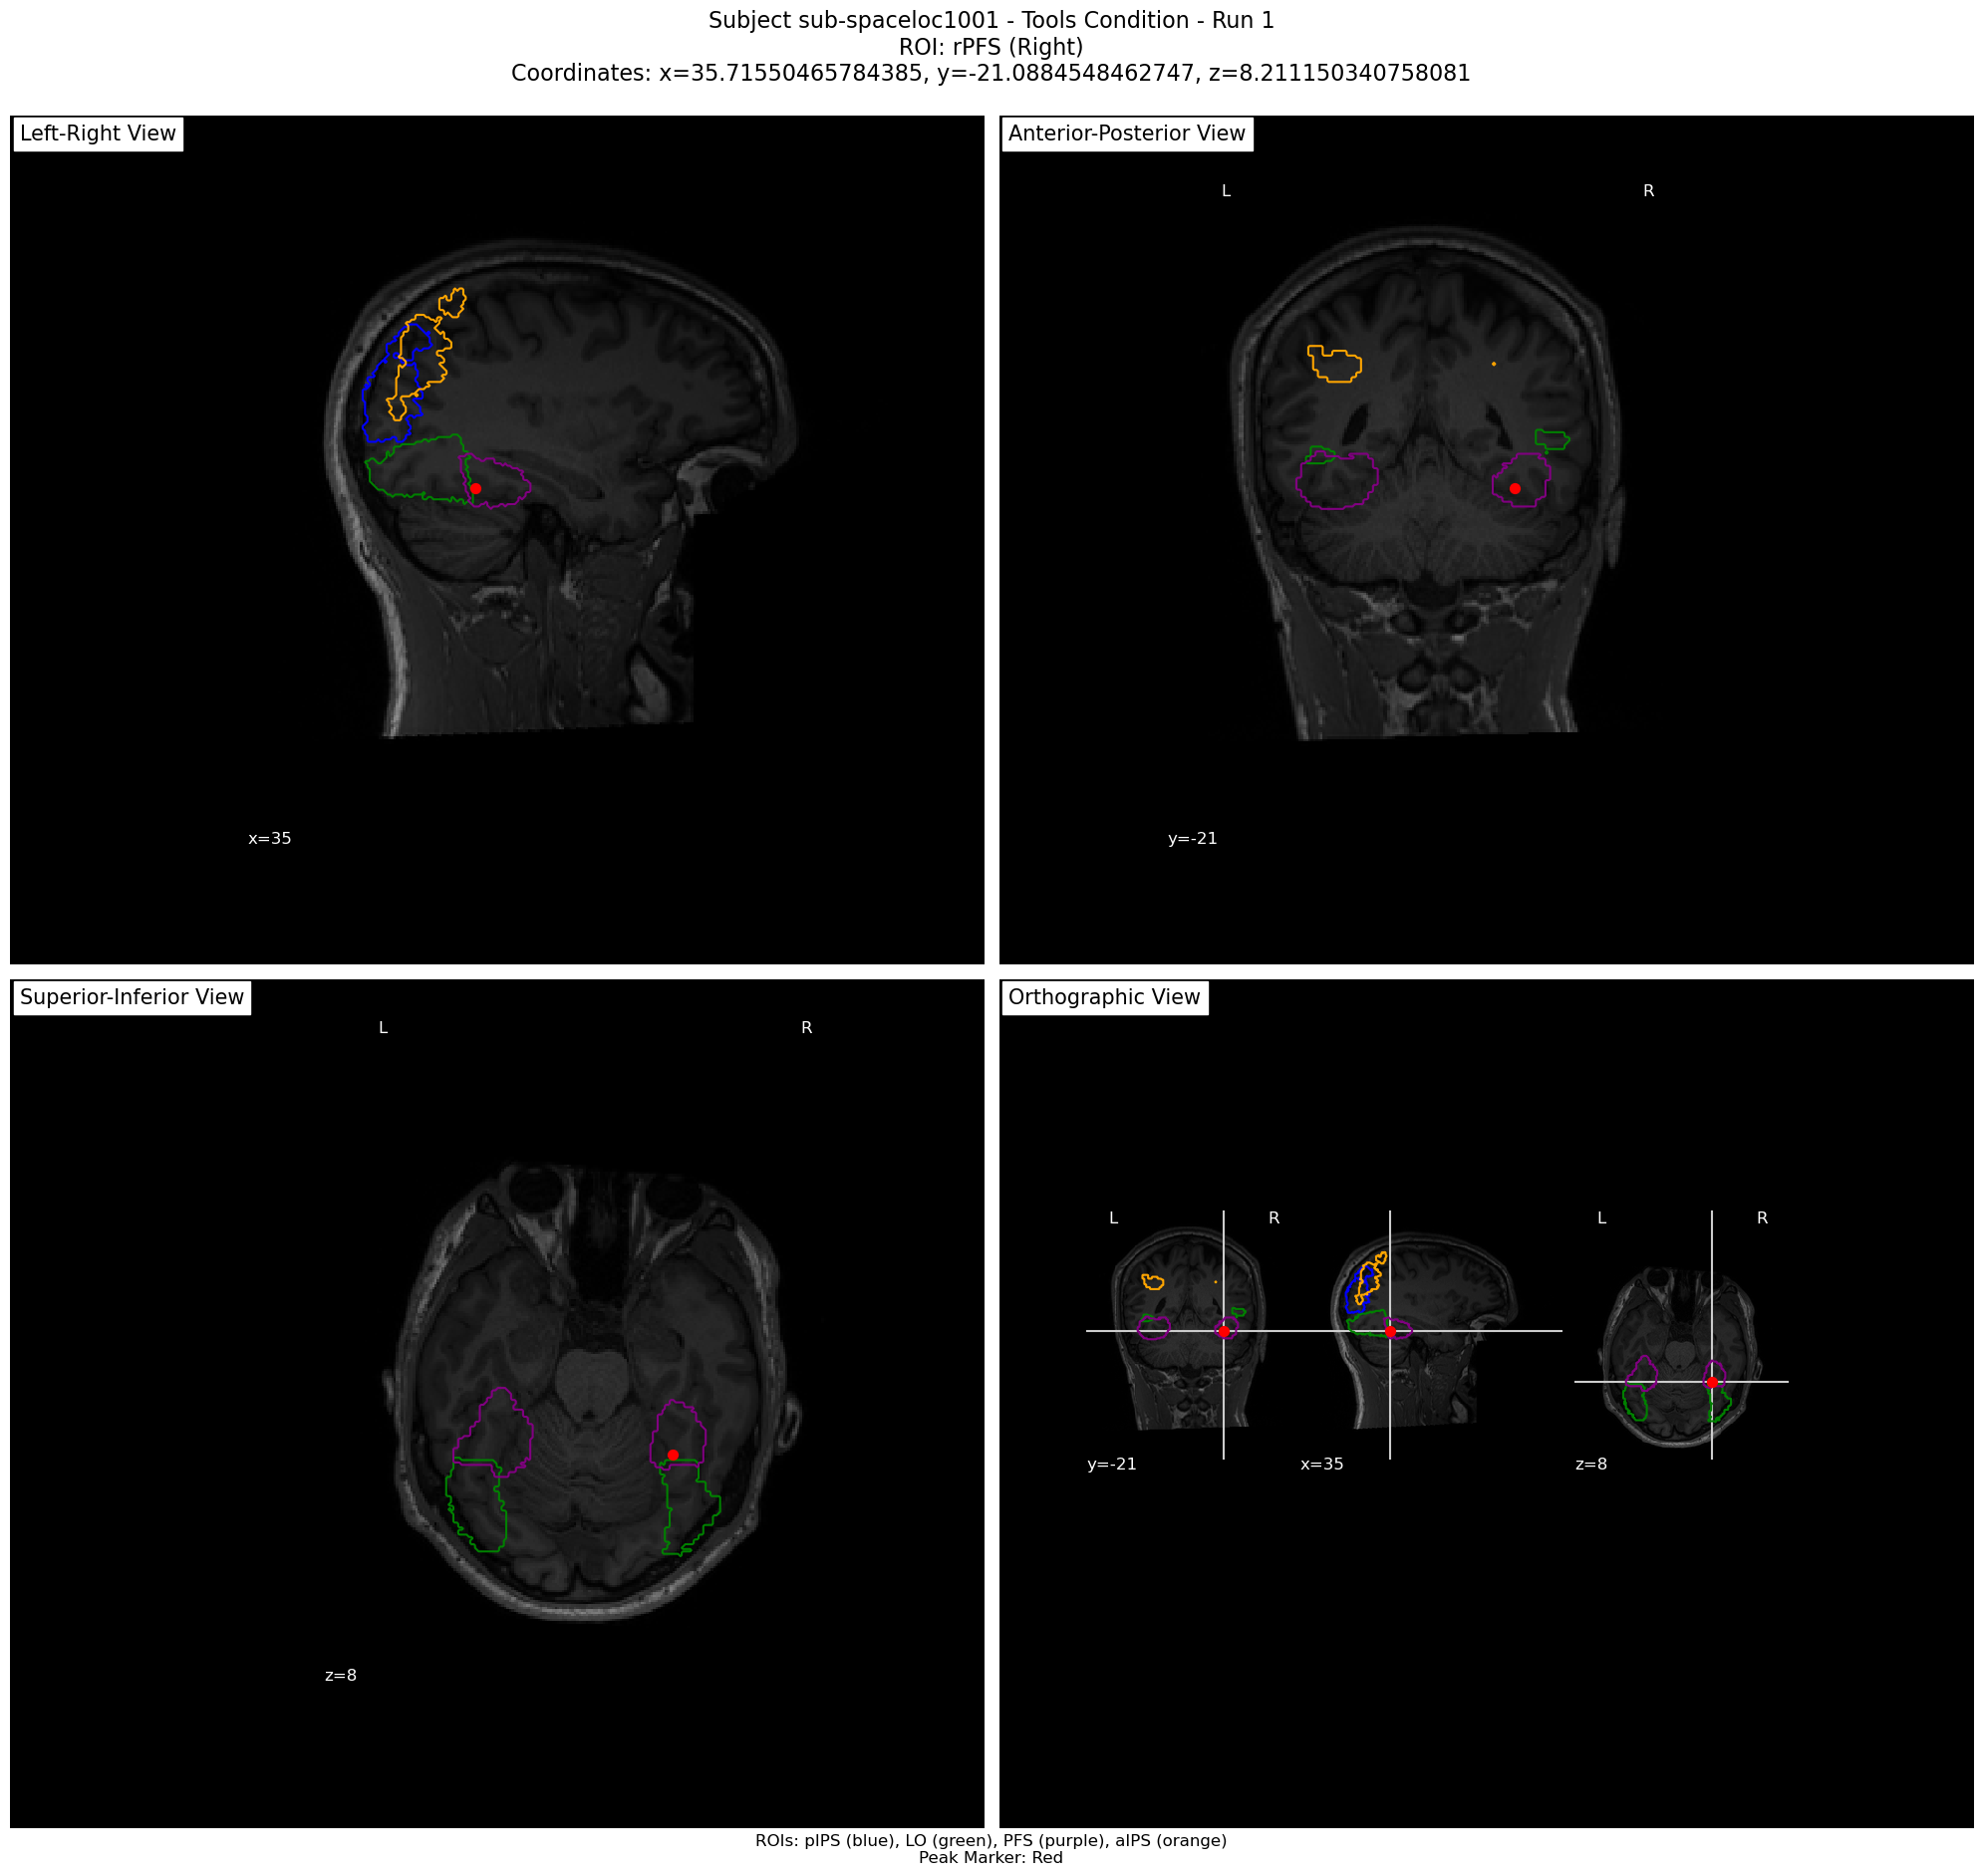

/tmp/ipykernel_9940/3768176061.py:100: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


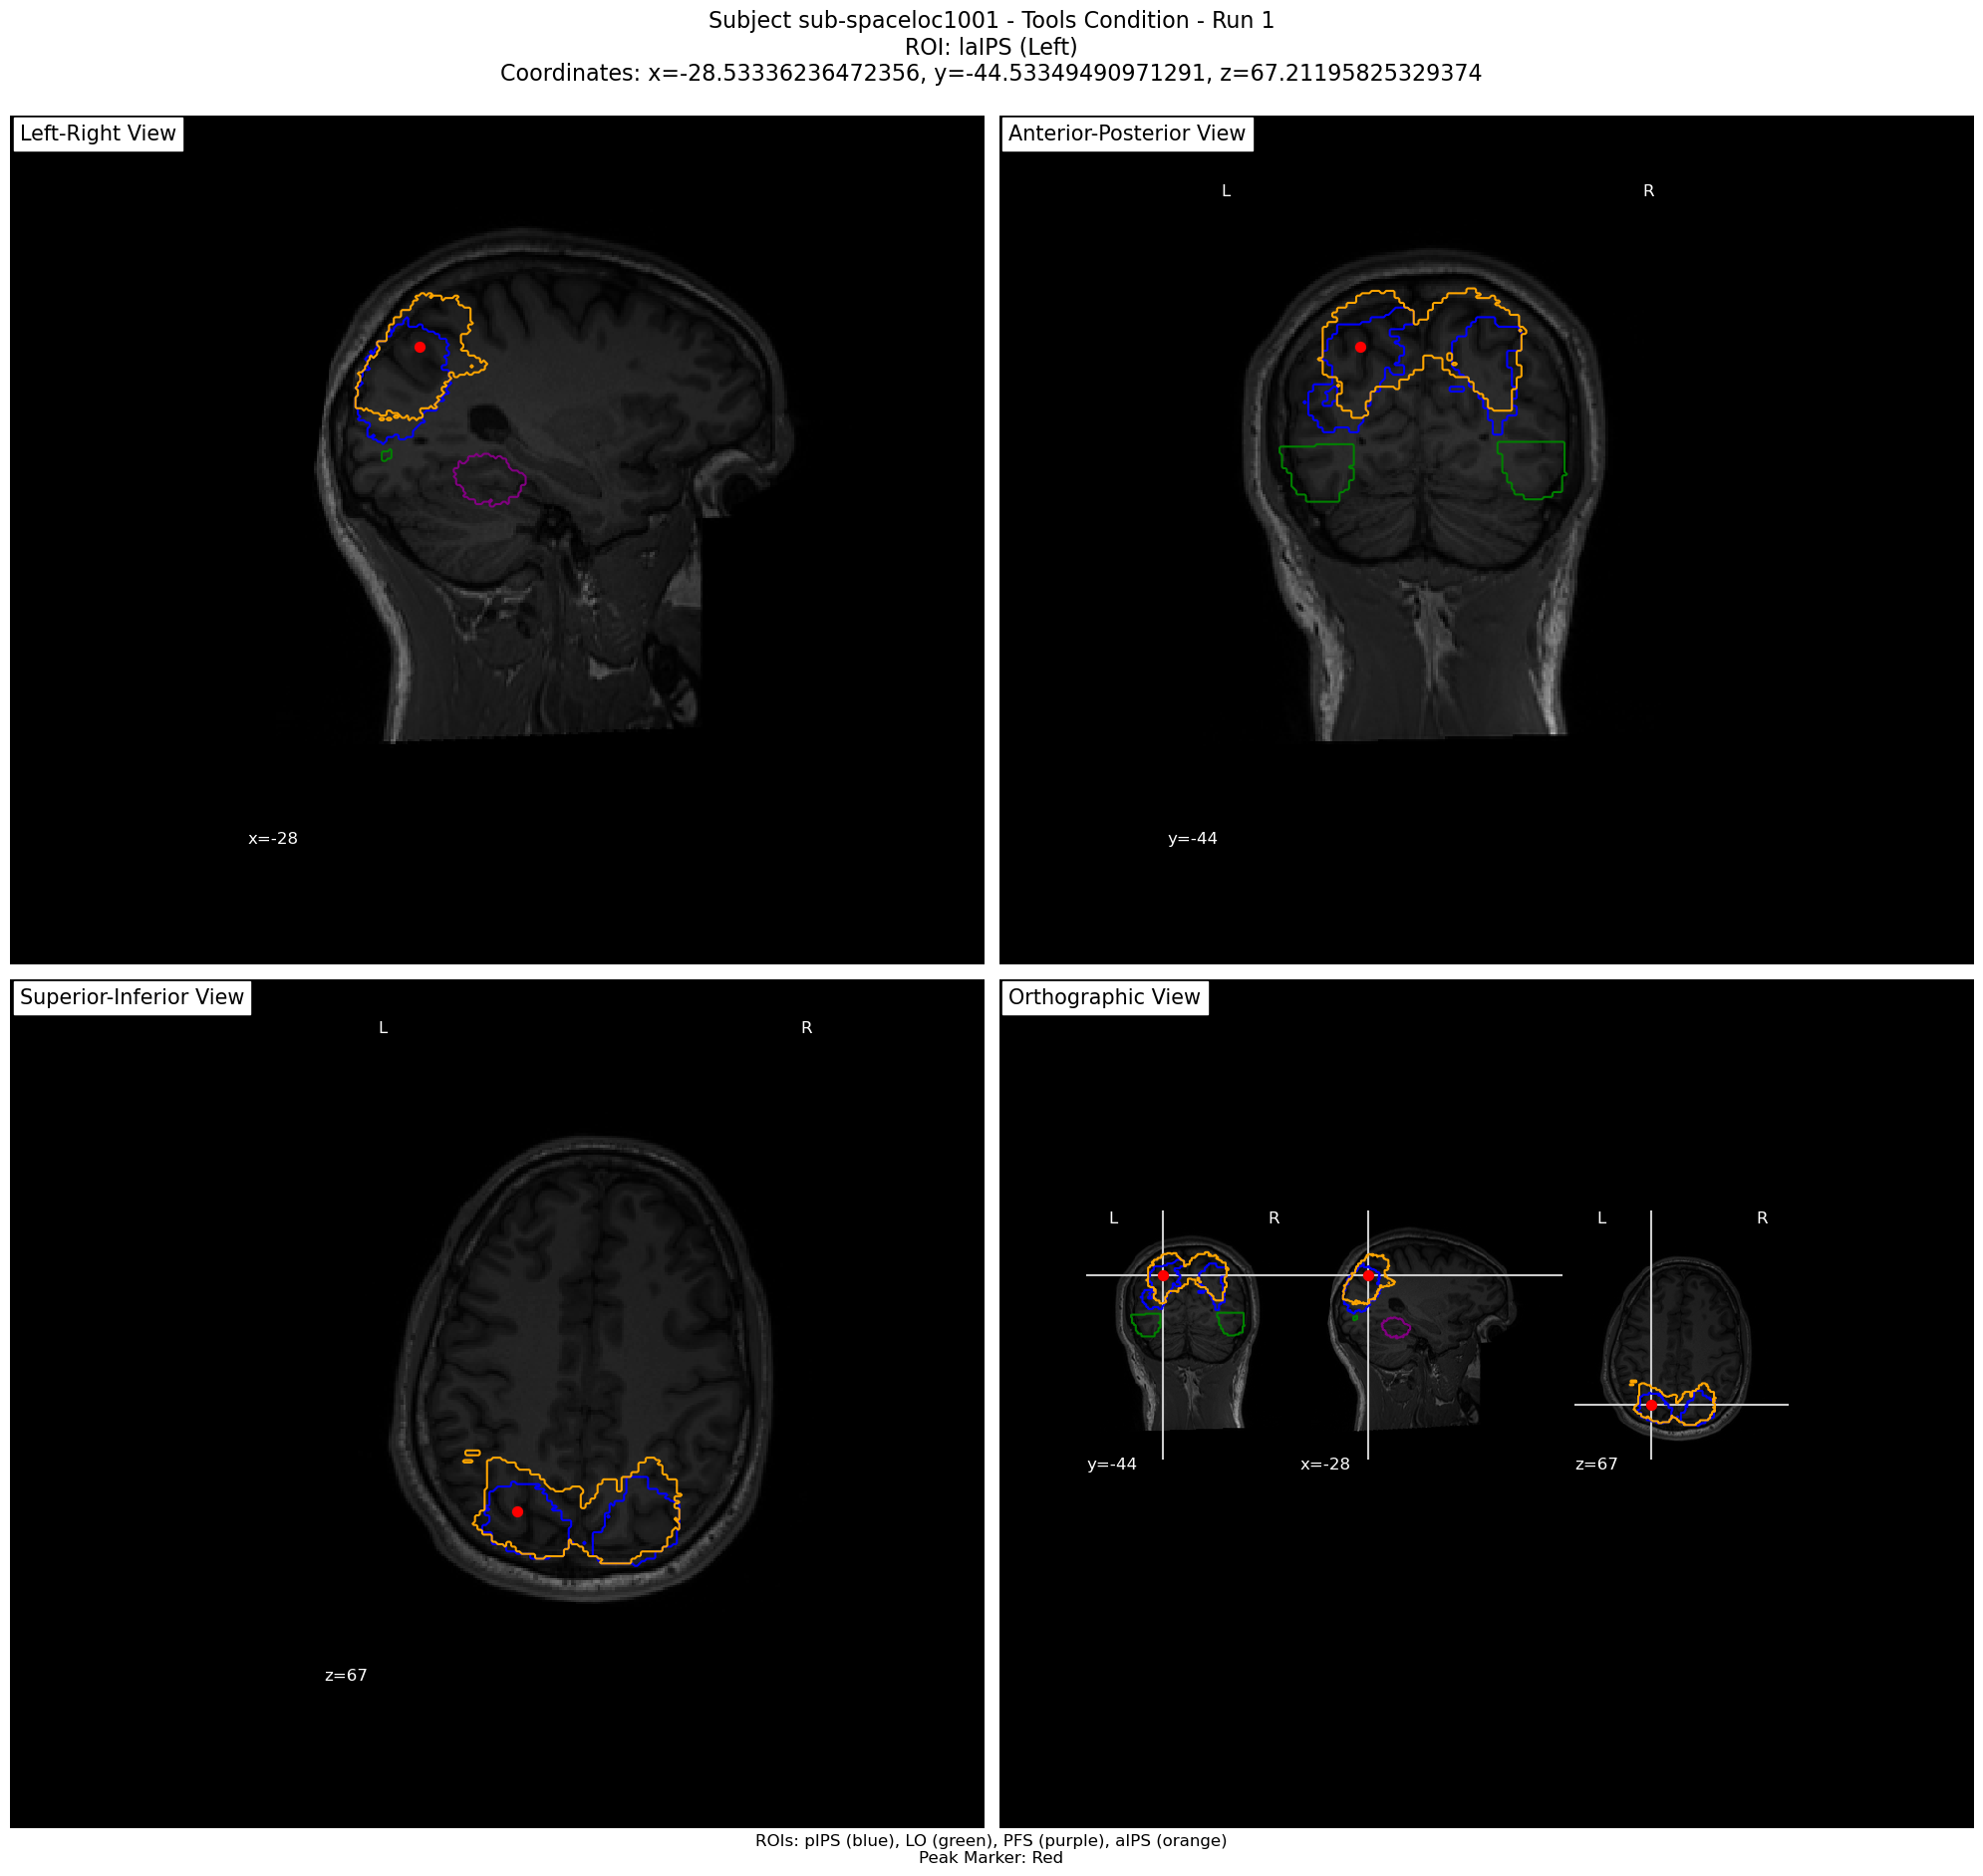

/tmp/ipykernel_9940/3768176061.py:100: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


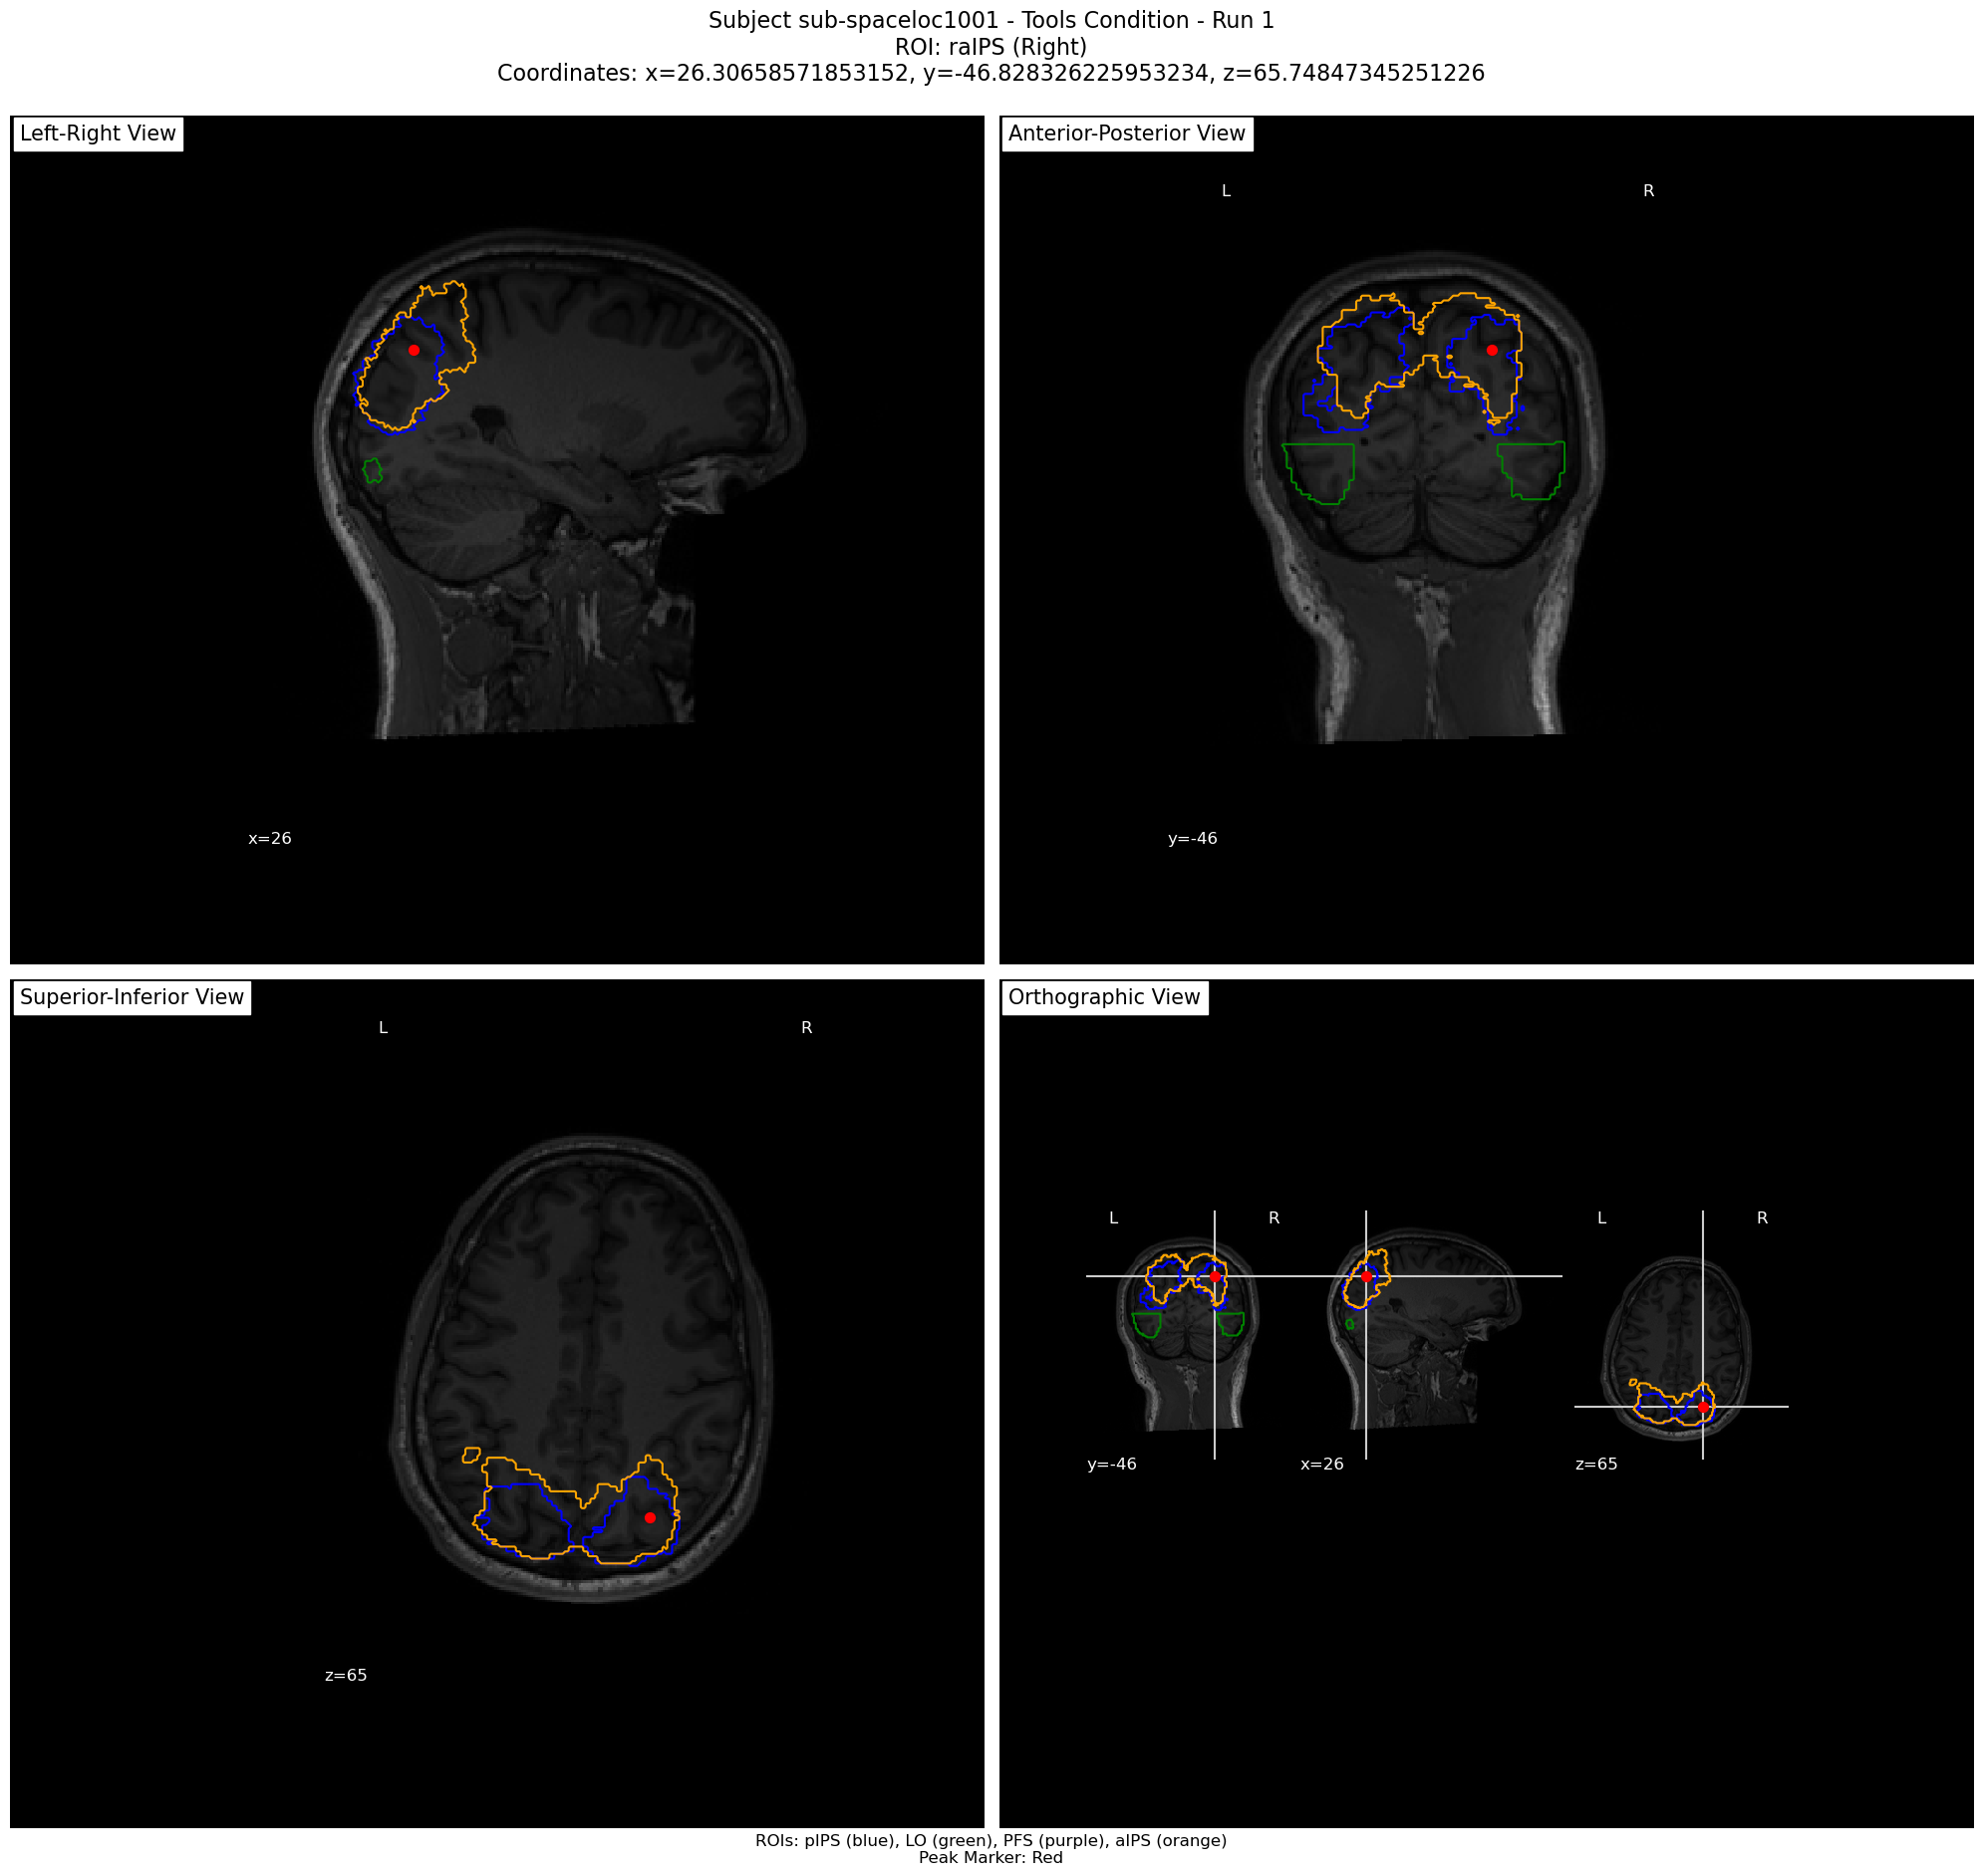

In [1]:
# roi visual 
import os
import pandas as pd
import numpy as np
from nilearn import plotting, image
import matplotlib.pyplot as plt
import ptoc_params as params

# Reuse the directory paths
raw_dir = params.raw_dir
sub_dir = '/user_data/csimmon2/temp_derivatives/{sub}/ses-01'
roi_dir = os.path.join(raw_dir, '{sub}/ses-01/derivatives/rois')
parcel_dir = os.path.join(raw_dir, '{sub}/ses-01/derivatives/rois/parcels')

# Read the coordinates file
coords_df = pd.read_csv('/user_data/csimmon2/git_repos/ptoc/tools/roi_coordinates.csv')

def plot_peak_views(subject_id='sub-spaceloc1001', condition='tools', run=1):
    """
    Create separate views for each peak coordinate showing different anatomical perspectives.
    """
    # Load the anatomical image
    anat_path = os.path.join(raw_dir, f"{subject_id}/ses-01/anat/{subject_id}_ses-01_T1w.nii.gz")
    anat_img = image.load_img(anat_path)

    # Get subject-specific coordinates for the specified run
    subject_coords = coords_df[
        (coords_df['subject'] == subject_id) & 
        (coords_df['condition'] == condition) &
        (coords_df['run_combo'] == run)
    ]

    # Define ROI colors
    roi_colors = {
        'pIPS': 'blue',
        'LO': 'green',
        'PFS': 'purple',
        'aIPS': 'orange'
    }

    # Create separate plots for each peak coordinate
    for idx, row in subject_coords.iterrows():
        # Determine hemisphere based on x-coordinate
        hemisphere = 'Left' if row['x'] < 0 else 'Right'

        # Create figure with different views
        fig, axes = plt.subplots(2, 2, figsize=(20, 20))
        plt.suptitle(f"Subject {subject_id} - {condition.capitalize()} Condition - Run {run}\n"
                    f"ROI: {row['roi']} ({hemisphere})\n"
                    f"Coordinates: x={row['x']}, y={row['y']}, z={row['z']}", 
                    y=0.95, fontsize=16)

        # Different view configurations
        views = [
            ('x', axes[0,0], 'Left-Right View'),
            ('y', axes[0,1], 'Anterior-Posterior View'),
            ('z', axes[1,0], 'Superior-Inferior View'),
            ('ortho', axes[1,1], 'Orthographic View')
        ]

        for view_dim, ax, title in views:
            # Create display for each view
            if view_dim == 'ortho':
                display = plotting.plot_anat(
                    anat_img,
                    display_mode='ortho',
                    cut_coords=(row['x'], row['y'], row['z']),  # Center on peak coordinate
                    axes=ax,
                    title=title
                )
            else:
                # For single plane views, use the coordinate for the current dimension
                coord_map = {'x': row['x'], 'y': row['y'], 'z': row['z']}
                display = plotting.plot_anat(
                    anat_img,
                    display_mode=view_dim,
                    cut_coords=[coord_map[view_dim]],  # Center on peak coordinate for this dimension
                    axes=ax,
                    title=title
                )

            # Add ROI contours
            for parcel, color in roi_colors.items():
                roi_path = os.path.join(parcel_dir.format(sub=subject_id), f"{parcel}.nii.gz")
                if os.path.exists(roi_path):
                    roi_img = image.load_img(roi_path)
                    display.add_contours(roi_img, colors=color, linewidths=1.5, levels=[0.5])

            # Add peak coordinate marker in red
            display.add_markers(
                np.array([[row['x'], row['y'], row['z']]]),
                marker_color='red',
                marker_size=50
            )

        # Add legend for ROIs
        legend_text = "ROIs: " + ", ".join([f"{roi} ({color})" for roi, color in roi_colors.items()])
        legend_text += "\nPeak Marker: Red"
        plt.figtext(0.5, 0.02, legend_text, ha='center', fontsize=12)

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        
        yield fig  # Return each figure as it's created

# Generate plots
# Example usage:
for fig in plot_peak_views(run=1):
    plt.show()

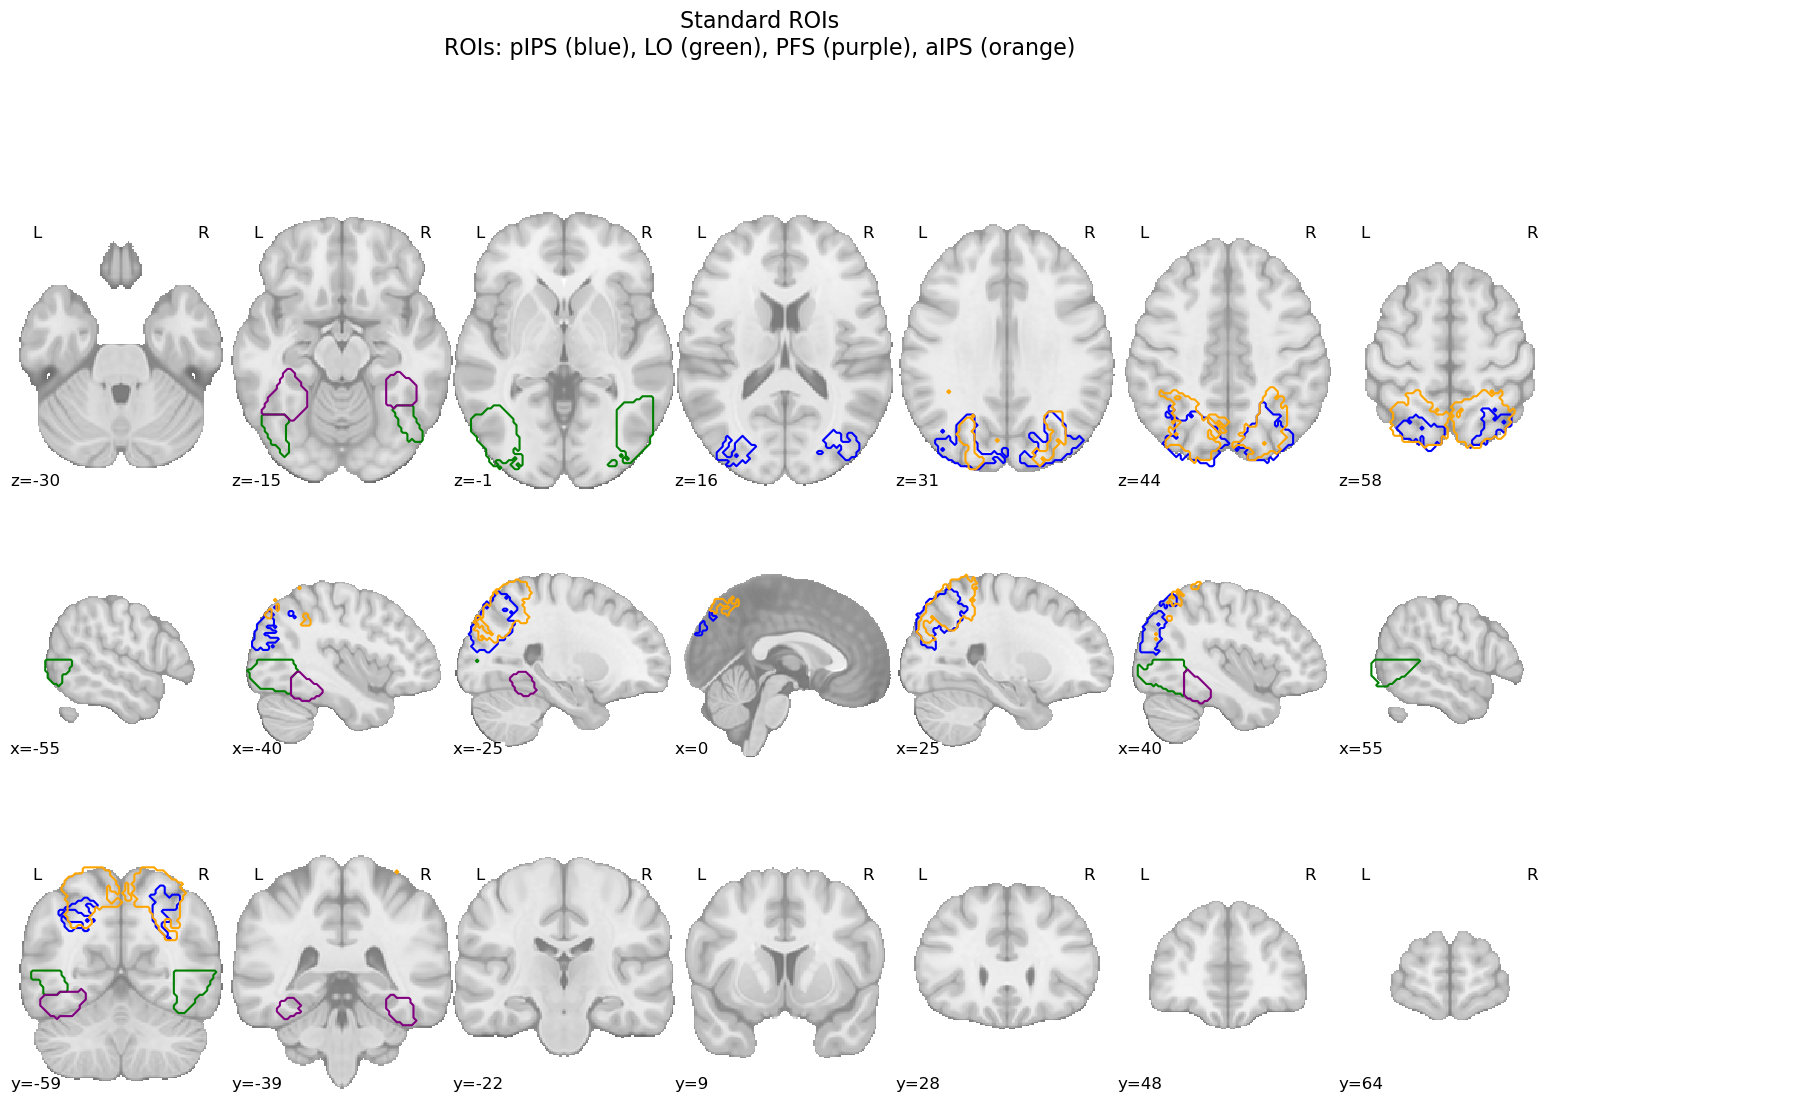

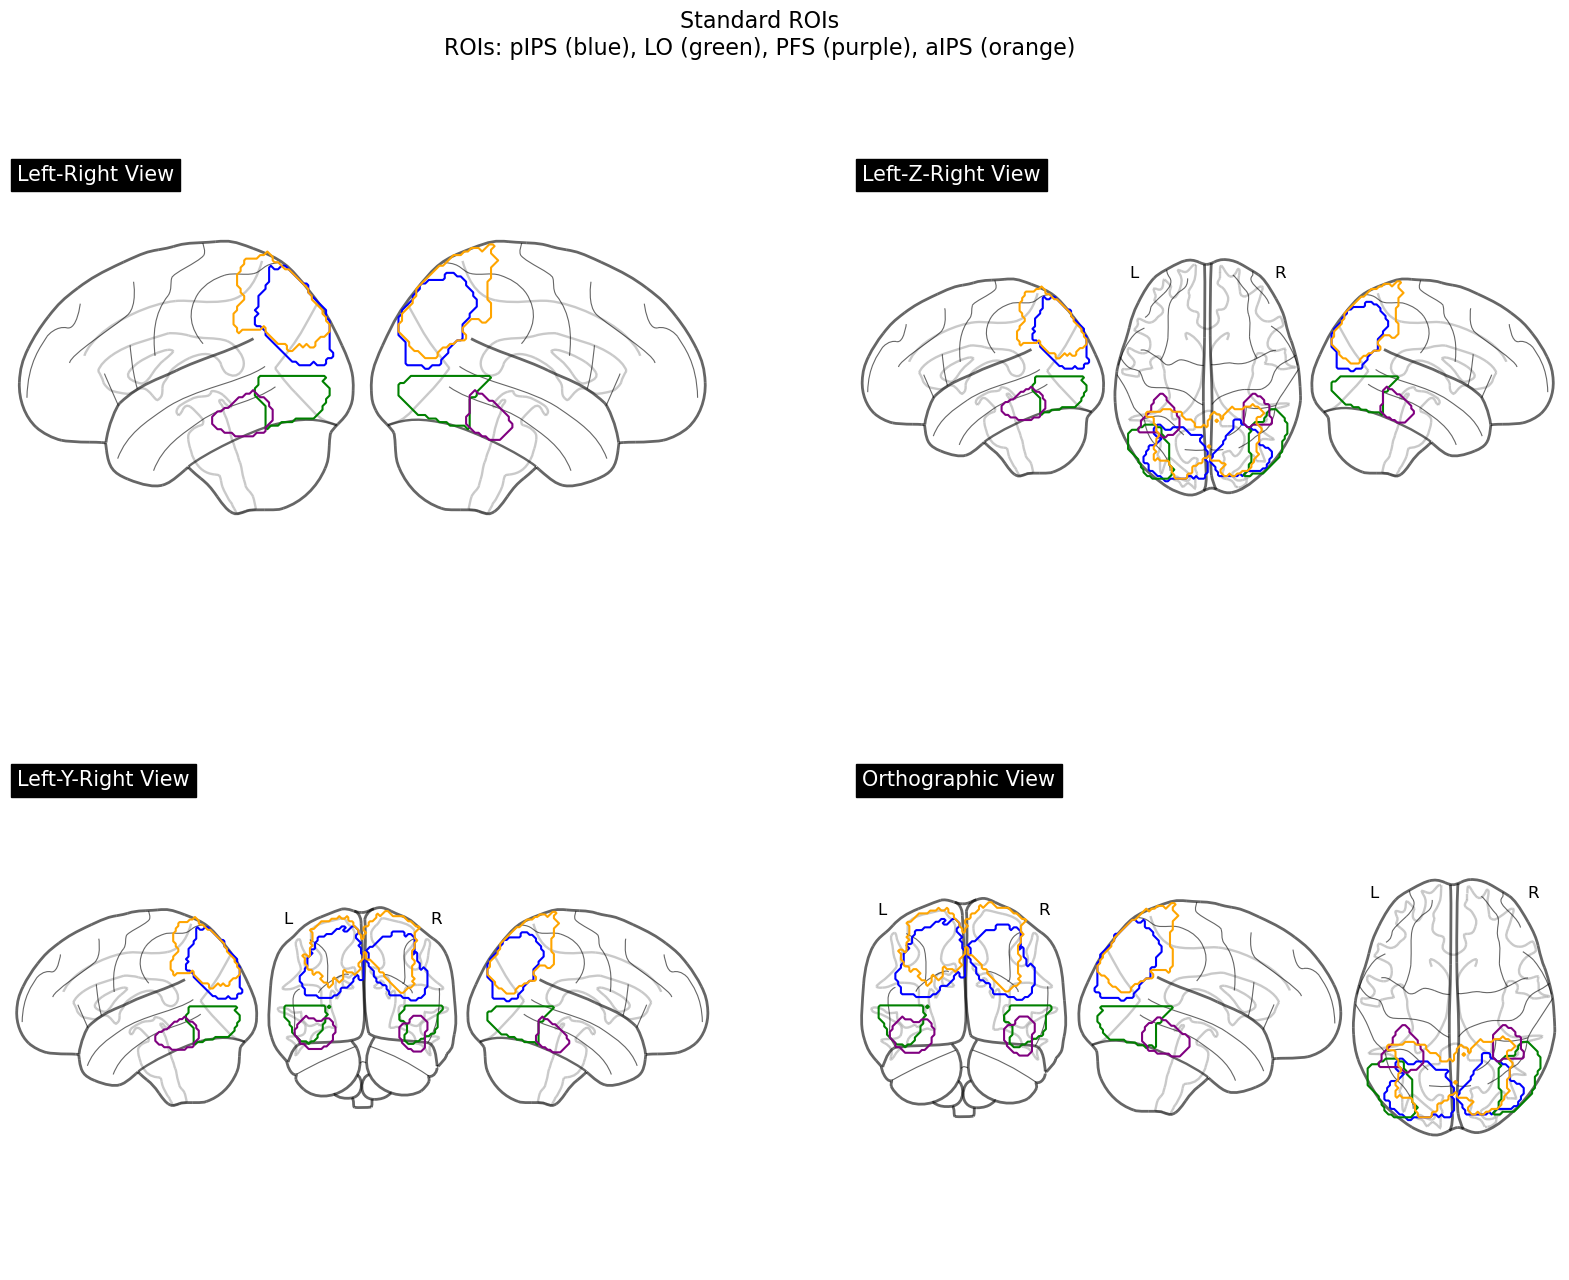

In [17]:
# plotting roi visual
import os
import numpy as np
from nilearn import plotting, image
import matplotlib.pyplot as plt

def plot_standard_rois(plot_type='mosaic'):
    """
    Plot standard ROI parcels on standard brain.
    
    Args:
        plot_type (str): Either 'mosaic' or 'glass_brain'
    """
    # Define the path to standard ROIs
    std_parcel_dir = '/user_data/csimmon2/git_repos/ptoc/roiParcels'
    
    # Define distinct colors for each ROI
    roi_colors = {
        'pIPS': 'blue',
        'LO': 'green',
        'PFS': 'purple',
        'aIPS': 'orange'
    }
    
    if plot_type == 'mosaic':
        # Create a figure with adjusted height for title
        fig = plt.figure(figsize=(20, 12))
        
        # Create the mosaic display
        display = plotting.plot_anat(
            display_mode='mosaic',
            draw_cross=False,
            annotate=True,
            axes=plt.gca()
        )
        
        # Plot each ROI parcel with its specific color
        for parcel, color in roi_colors.items():
            roi_path = os.path.join(std_parcel_dir, f"{parcel}.nii.gz")
            if os.path.exists(roi_path):
                roi_img = image.load_img(roi_path)
                display.add_contours(roi_img, colors=color, linewidths=1.5, levels=[0.5])
        
        # Add title with ROI information
        plt.suptitle("Standard ROIs\n" + 
                    "ROIs: " + 
                    ", ".join([f"{roi} ({color})" for roi, color in roi_colors.items()]),
                    y=0.95, fontsize=16)
        
    elif plot_type == 'glass_brain':
        # Create a figure
        fig = plt.figure(figsize=(20, 15))
        
        # Create displays for different views
        views = {
            'lr': (221, 'Left-Right View'),
            'lzr': (222, 'Left-Z-Right View'),
            'lyr': (223, 'Left-Y-Right View'),
            'ortho': (224, 'Orthographic View')
        }
        
        for view, (position, title) in views.items():
            ax = plt.subplot(position)
            display = plotting.plot_glass_brain(
                None,
                display_mode=view,
                plot_abs=False,
                alpha=0.6,
                axes=ax,
                title=title
            )
            
            # Plot each ROI parcel
            for parcel, color in roi_colors.items():
                roi_path = os.path.join(std_parcel_dir, f"{parcel}.nii.gz")
                if os.path.exists(roi_path):
                    roi_img = image.load_img(roi_path)
                    display.add_contours(roi_img, colors=color, linewidths=1.5, levels=[0.5])
        
        # Add title with legend information, positioned higher
        plt.suptitle("Standard ROIs\n" + 
                    "ROIs: " + 
                    ", ".join([f"{roi} ({color})" for roi, color in roi_colors.items()]),
                    y=0.95, fontsize=16)
        
        # Adjust subplot spacing to prevent title overlap
        plt.subplots_adjust(top=0.85)
    
    return fig

# Example usage:
# For mosaic view
fig_mosaic = plot_standard_rois('mosaic')
plt.show()

# For glass brain view
fig_glass = plot_standard_rois('glass_brain')
plt.show()
